## Heat Pump with Dummy Evaporator

In [ ]:
import os
import copy
import numpy as np
from scipy.optimize import brentq, newton
from tqdm import tqdm

# vclibpy Imports
from vclibpy import FlowsheetState, Inputs, RelativeCompressorSpeedControl, HeatExchangerInputs
from vclibpy.media import RefProp
from vclibpy.components.compressors import ConstantEffectivenessCompressor
from vclibpy.components.heat_exchangers import MovingBoundaryNTUCondenser
from vclibpy.components.heat_exchangers.heat_transfer.constant import (
    ConstantHeatTransfer, ConstantTwoPhaseHeatTransfer
)
from vclibpy.components.heat_exchangers.heat_transfer.wall import WallTransfer

from vclibpy.media import RefProp, ThermodynamicState, TransportProperties
import os


REFPROP_DIR = r"C:\Program Files (x86)\REFPROP"    # directory that contains FLUIDS, MIXTURES, REFPRP64.DLL …
REFPROP_DLL = r"C:\Program Files (x86)\REFPROP\REFPRP64.DLL"

os.environ["RPPREFIX"] = REFPROP_DIR               # tell ctREFPROP where REFPROP lives



# =============================================================================
# CONFIGURATION & CONSTANTS
# =============================================================================


# --- Cycle Targets ---
TARGET_SUBCOOLING = 2.0         # K (Delta T below saturation)
TARGET_SUPERHEAT  = 5.0         # K (Delta T above saturation)
TARGET_Q_COND     = 4000.0      # W (Required Heating Capacity)

# --- Boundary Conditions ---
T_WATER_IN     = 273.15 + 30.0  # K
M_FLOW_WATER   = 0.20           # kg/s
AIR_TEMP_IN    = 273.15 + 7.0   # K

# --- Simulation Time ---
# Simulating 1 hour in 60s steps
TIME_STEPS = np.arange(0, 1200, 60) 


# =============================================================================
# SYSTEM INITIALIZATION
# =============================================================================
# med_prop = RefProp(fluid_name="R410A", z=[0.697615, 0.302385], dll_path=REFPROP_DLL, ref_prop_path=REFPROP_DIR)
# med_prop = RefProp(fluid_name="Propane", dll_path=REFPROP_DLL, ref_prop_path=REFPROP_DIR)

# med_prop = RefProp(
#     fluid_name="R32.FLD|R125.FLD",  # Fluids for R410A
#     z=[0.697615, 0.302385],         # Mole fractions for R410A
#     dll_path=REFPROP_DLL, 
#     ref_prop_path=REFPROP_DIR,
#     copy_dll=False
# )
# NEW (Robust Pseudo-Pure Definition)
med_prop = RefProp(
    fluid_name="R410A",  # Simple string usually works for RefProp 9.1/10
    # If that fails, try: fluid_name="R410A.FLD"
    # z is NOT needed for pseudo-pure fluids
    dll_path=REFPROP_DLL, 
    ref_prop_path=REFPROP_DIR,
    copy_dll=False
)



# Compressor
# compresultssor = ConstantEffectivenessCompressor(
#     N_max=100, 
#     V_h=80e-6, 
#     eta_isentropic=0.7,
#     eta_mech=0.9, 
#     lambda_h=0.9
# )

# Data from "https://areacooling.com/wp-content/uploads/product-documentation/C-SDP205H02B%20R410A%20Specification.pdf"
compressor = ConstantEffectivenessCompressor(
    N_max=90,           # Datasheet: 90 Hz
    V_h=42.3e-6,          # Datasheet: 42.3 cm³
    eta_isentropic=0.7,   # No data on typenschild, use typical value
    eta_mech=0.9,         # No data on typenschild, use typical value
    lambda_h=0.9          # No data on typenschild, use typical value
)
compressor.med_prop = med_prop

# Condenser (Hardware Model)
# condenser = MovingBoundaryNTUCondenser(
#     A=3.0, 
#     secondary_medium="Water", 
#     flow_type="counter",
#     ratio_outer_to_inner_area=1.0,
#     two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=5000),
#     gas_heat_transfer=ConstantHeatTransfer(alpha=800),
#     liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),
#     wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.002),
#     secondary_heat_transfer=ConstantHeatTransfer(alpha=3000)
# )

# Data from ""N:\Forschung\EBC1078_BMWK_Avoid_KAP\Students\Project-Exchange\Experimental_Data\OptiHorst\Daten\Dynamik\mapping\mapping.xlsx""
condenser = MovingBoundaryNTUCondenser(
    A=3.53,                                                            # Exact value from datasheet
    secondary_medium="Water",                                          # Standard medium
    flow_type="counter",                                               # Typical for Plate Heat Exchangers
    ratio_outer_to_inner_area=1.0,                                     # Symmetric plates
    two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=4000),  # R410A condensation (Typ. 2500-5500 W/m2K)
    gas_heat_transfer=ConstantHeatTransfer(alpha=500),                 # Desuperheating gas (Typ. 200-800 W/m2K)
    liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),             # Subcooling liquid (Typ. 800-1200 W/m2K)
    wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.0004),     # Stainless steel (Typ. 0.3-0.4 mm plates)
    secondary_heat_transfer=ConstantHeatTransfer(alpha=4000)           # Water side turbulent (Typ. 3000-6000 W/m2K)
)
condenser.med_prop = med_prop

# Initialize Secondary Side (Water)
condenser.start_secondary_med_prop()
condenser.m_flow_secondary = M_FLOW_WATER
condenser.calc_secondary_cp(T=T_WATER_IN, p=1e5)

CONDENSER_SECONDARY_INPUTS = Inputs(
    condenser=HeatExchangerInputs(T_in=T_WATER_IN, m_flow=M_FLOW_WATER)
)

# =============================================================================
# PHYSICS HELPER FUNCTIONS
# =============================================================================

def dummy_evaporator_model(m_flow, h4_in, p_evap, current_time):
    """
    A simplified model of an evaporator that includes frosting degradation.
    
    Args:
        m_flow (float): Refrigerant mass flow [kg/s]
        h4_in (float): Enthalpy entering evaporator [J/kg]
        p_evap (float): Evaporation pressure [Pa]
        current_time (float): Simulation time [s]
        
    Returns:
        h1_actual (float): The actual enthalpy leaving the evaporator.
    """
    # --- DEGRADATION PARAMETERS (Local) ---
    # 1. Get the simulation end time dynamically from the global TIME_STEPS
    sim_end_time = float(TIME_STEPS[-1])
    
    # 2. Define the target capacity at the end (e.g., 0.5 = 50%)
    target_end_factor = 0.3
    
    # 3. Define the curve shape (Exponent)
    #    - 1.0 = Linear drop (diagonal line)
    #    - 2.0 = Parabolic drop
    #    - 5.0+ = Stays flat/stable for a long time, then drops very sharply at the end
    curve_shape = 3.0

    # --- CALCULATION ---
    # Formula: Factor = 1.0 - (Max_Drop * (Progress)^Shape)
    # This guarantees Factor=1.0 at t=0, and Factor=target_end_factor at t=end
    if sim_end_time > 0:
        progress = current_time / sim_end_time
        frost_factor = 1.0 - (1.0 - target_end_factor) * (progress ** curve_shape)
    else:
        frost_factor = 1.0

    # Apply factor to UA (Overall Heat Transfer Coefficient)
    UA_actual = 1500.0 * frost_factor
    
    # --- PHYSICS (NTU Method) ---
    cp_air = 1005.0
    m_air = 0.8  # kg/s
    
    # Calculate Saturation Temp (uses global 'med_prop')
    t_evap_sat = med_prop.calc_state("PQ", p_evap, 0.5).T
    
    # Maximum theoretical heat transfer (infinite area)
    # Uses global 'AIR_TEMP_IN'
    Q_max = m_air * cp_air * (AIR_TEMP_IN - t_evap_sat)
    
    # Limit Q_max: cannot transfer heat if refrigerant is warmer than air
    Q_max = max(0, Q_max)
    
    # Actual effectiveness
    NTU = UA_actual / (m_air * cp_air)
    epsilon = 1 - np.exp(-NTU)
    
    Q_actual = epsilon * Q_max
    
    # Energy Balance: h_out = h_in + Q / m_dot
    h1_actual = h4_in + (Q_actual / m_flow)
    
    return h1_actual

# =============================================================================
# SOLVER LOGIC (High Side)
# =============================================================================

def solve_high_side(p_evap, h1_target):
    """
    Solves the High Pressure side (Compressor + Condenser).
    
    This function contains the LEVEL 1 (Compression) and LEVEL 2 (Condensation) loops.
    
    Args:
        p_evap (float): Evaporation Pressure [Pa]
        h1_target (float): Target Suction Enthalpy [J/kg]
    
    Returns:
        Tuple: (p_cond, m_flow, h2, h3, h4, speed, iterations)
    """
    fs_state = FlowsheetState()
    
    # Set Compressor Inlet State (Point 1)
    compressor.state_inlet = med_prop.calc_state("PH", p_evap, h1_target)

    # Variable to store the last calculated speed to speed up next guess
    solver_cache = {"last_speed": 0.5, "calls": 0}

    # ---------------------------------------------------------------------------------------------------------------------
    # COMPONENT HELPERS
    # ---------------------------------------------------------------------------------------------------------------------
    def calc_compressor_step(n_speed, p_discharge):
        """Runs compressor model. Returns: m_dot and h2"""
        ctrl = RelativeCompressorSpeedControl(n=n_speed)
        inputs = Inputs(control=ctrl)
        
        m_dot = compressor.calc_m_flow(inputs=inputs, fs_state=fs_state)
        compressor.calc_state_outlet(p_outlet=p_discharge, inputs=inputs, fs_state=fs_state)
        
        return m_dot, compressor.state_outlet.h

    def calc_condenser_step(m_dot, h_inlet, p_pressure):
        """Runs condenser hardware model. Returns: h3, balance_error"""
        # Set Condenser Inlet State
        condenser.m_flow = m_dot
        condenser.state_inlet = med_prop.calc_state("PH", p_pressure, h_inlet)
        
        # Set Target Outcome (Subcooled Liquid)
        t_sat = med_prop.calc_state("PQ", p_pressure, 0).T
        condenser.state_outlet = med_prop.calc_state("PT", p_pressure, t_sat - TARGET_SUBCOOLING)
        
        # Calculate Hardware Performance
        error, _ = condenser.calc(inputs=CONDENSER_SECONDARY_INPUTS, fs_state=fs_state)
        return condenser.state_outlet.h, error

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 1 SOLVER: The "Compression Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Compressor Speed (n) to meet Heating Demand.
    # LOGIC:
    #   1. GUESS Speed (n).
    #   2. PHYSICS: Calculate mass flow (m_dot) and discharge enthalpy (h2).
    #   3. CHECK: Does Q_generated (m_dot * delta_h) match Target (TARGET_Q_COND)?
    #   4. RESIDUAL: Q_generated - Target. (Adjust 'n' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def run_compression_loop(p_cond_current):
        
        # Calculate Target Enthalpy for Point 3 (Subcooled) for the current p_cond guess
        t_sat = med_prop.calc_state("PQ", p_cond_current, 0).T
        h3_target = med_prop.calc_state("PT", p_cond_current, t_sat - TARGET_SUBCOOLING).h

        def compression_residual(n_guess):
            # Run Compressor Physics
            m_dot, h2 = calc_compressor_step(n_guess, p_cond_current)
            
            # Calculate theroetical thermodynamic heat capacity
            q_calc = m_dot * (h2 - h3_target)
            return q_calc - TARGET_Q_COND

        # Solve for Compressor Speed
        try:
            n_solved = brentq(f=compression_residual, a=0.05, b=1.0, xtol=0.005)
            solver_cache["last_speed"] = n_solved
            return n_solved
        except ValueError:
            # --- DEBUGGING INSERT START ---
            r_min = compression_residual(0.05)
            r_max = compression_residual(1.0)
            # print(f"\n[L1 FAIL] Speed Loop. Target Q: {TARGET_Q_COND}")
            # print(f"  At Min Speed (0.05): Q_error = {r_min:.1f}")
            # print(f"  At Max Speed (1.0): Q_error = {r_max:.1f}")
            # --- DEBUGGING INSERT END ---
            return solver_cache["last_speed"]

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 2 SOLVER: The "Condensation Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Condenser Pressure (p_cond) to enable heat rejection.
    # LOGIC:
    #   1. GUESS Pressure (p_cond).
    #   2. DEMAND: Calculate heat (Q_req) needed to cool from Inlet -> Subcooled.
    #   3. CAPABILITY: Ask Hardware (UA, LMTD) how much heat (Q_hard) it 
    #      CAN actually transfer at this pressure/temp difference (with its area etc.).
    #   4. RESIDUAL: Q_hard - Q_req. (Adjust 'p_cond' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def condensation_residual(p_cond_guess):
        solver_cache["calls"] += 1
        
        # Run Level 1 (Compression Loop) to get speed for the current p_cond guess
        n_speed = run_compression_loop(p_cond_guess)
        
        # Run the Compressor Physics with that speed
        m_dot, h2 = calc_compressor_step(n_speed, p_cond_guess)
        
        # Check if Hardware matches Thermodynamics
        _, error = calc_condenser_step(m_dot, h2, p_cond_guess)
        
        return error

    # Execute Level 2 Solver
    try:
        # Range adjusted to stay below critical pressure (Pc is approx 33.9 bar for this mixture)
        p_cond_final = brentq(f=condensation_residual, a=10e5, b=33.8e5, xtol=500)
    except ValueError:
        # --- DEBUGGING INSERT START ---
        r_a = condensation_residual(10e5)
        r_b = condensation_residual(33.8e5)
        print(f"\n[L2 FAIL] Condenser Pressure Loop.")
        print(f"  At 15 bar: Error = {r_a:.1f}")
        print(f"  At 33 bar: Error = {r_b:.1f}")
        # --- DEBUGGING INSERT END ---
        p_cond_final = 25e5  # Safe fallback for R410A

    # ---------------------------------------------------------------------------------------------------------------------
    # FINALIZE (Re-run physics to get final points)
    # ---------------------------------------------------------------------------------------------------------------------
    final_speed = run_compression_loop(p_cond_final)
    
    # Final Compressor Run
    m_flow_final, h2_final = calc_compressor_step(final_speed, p_cond_final)
    
    # Final Condenser Run
    h3_final, _ = calc_condenser_step(m_flow_final, h2_final, p_cond_final)
    
    # Expansion (Isenthalpic)
    h4_final = h3_final

    return p_cond_final, m_flow_final, h2_final, h3_final, h4_final, final_speed, solver_cache["calls"]


# =============================================================================
# MAIN SIMULATION LOOP
# =============================================================================

def run_simulation():
    """
    Main time-stepping loop.
    Contains the LEVEL 3 Solver ("Evaporation Loop").
    """
    # Result Containers
    res = {
        "time": [], "m_flow": [], "p_evap": [], "p_cond": [], 
        "Q_evap": [], "Q_cond": [], "P_el": [], "COP": [], "speed": [],
        "h1": [], "h2": [], "h3": [], "h4": [],
        "cycles": [], "iterations": {"Level 2": [], "Level 3": []}
    }

    print("Starting Simulation...")

    for i, t in enumerate(tqdm(TIME_STEPS)):
        # Iteration Counters for this time step
        step_counters = [0, 0]
        
        # ------------------------------------------------------------------------------------------------------
        # LEVEL 3 SOLVER: The "Evaporation Loop"
        # ------------------------------------------------------------------------------------------------------
        # OBJECTIVE: Find Evaporator Pressure (P_evap) to match the heat source and superheat target.
        # LOGIC:
        #   1. GUESS Pressure (P_evap).
        #   2. TARGET: Define required evaporator outlet state (Sat + 5K Superheat).
        #   3. SYSTEM: Solve High Side to get mass flow (m_dot) and inlet (h4) to meet (TARGET_Q_COND).
        #   4. PHYSICS: Run Evaporator model to see actual outlet (h1_actual).
        #   5. RESIDUAL: h1_actual - h1_target. (Adjust P to balance).
        # ------------------------------------------------------------------------------------------------------
        
        def evaporation_residual(p_evap_trial):
            step_counters[0] += 1 # Count Level 3 call
            
            # Calculate Target h1 (Saturation + Superheat)
            t_sat_ev = med_prop.calc_state("PQ", p_evap_trial, 0).T
            h1_target = med_prop.calc_state("PT", p_evap_trial, t_sat_ev + TARGET_SUPERHEAT).h
            
            # Solve Level 2 (High Side: Condenser + Compressor)
            _, m_f, _, _, h4_out, _, l2_iters = solve_high_side(p_evap_trial, h1_target)
            step_counters[1] += l2_iters
            
            # Run Evaporator Model (Expensive!!!)
            h1_actual = dummy_evaporator_model(m_f, h4_out, p_evap_trial, t)
            
            # Error
            return h1_actual - h1_target

        # Execute Level 3 Solver
        # Smart guessing: Use Newton for speed if we have history, otherwise Brentq
        p_evap_final = 8e5 # Default for R410A
        
        if i >= 2:
            # Predict next pressure based on previous slope
            slope = res["p_evap"][-1] - res["p_evap"][-2]
            p_guess = res["p_evap"][-1] + slope
            try:
                p_evap_final = newton(func=evaporation_residual, x0=p_guess, tol=100, maxiter=8)
            except (RuntimeError, ValueError):
                # If Newton diverges, fall back to safe Brentq
                try: 
                    p_evap_final = brentq(f=evaporation_residual, a=6e5, b=18e5, xtol=50)
                except ValueError: pass
        else:
            # First few steps, use robust solver
            try:
                # Range adjusted for R410A (Higher suction pressure)
                p_evap_final = brentq(f=evaporation_residual, a=4e5, b=13e5, xtol=50)
            except ValueError:
                # --- DEBUGGING INSERT START ---
                r_a = evaporation_residual(4e5)
                r_b = evaporation_residual(13e5)
                print(f"\n[L3 FAIL] Evaporator Loop (Time: {t}).")
                print(f"  At 4 bar: dH_error = {r_a:.1f}")
                print(f"  At 13 bar: dH_error = {r_b:.1f}")
                # --- DEBUGGING INSERT END ---
                break

        # Final Calculation
        # Now that we have P_evap, we run the full chain one last time to save data.
        
        # Get Final h1
        t_sat_ev = med_prop.calc_state("PQ", p_evap_final, 0).T
        h1 = med_prop.calc_state("PT", p_evap_final, t_sat_ev + TARGET_SUPERHEAT).h
        
        # Get High Side results
        p_cond, m_flow, h2, h3, h4, speed, _ = solve_high_side(p_evap_final, h1)
        
        # Calculate Electrical Power (requires specific compressor call)
        fs_final = FlowsheetState()
        inputs_final = Inputs(control=RelativeCompressorSpeedControl(n=speed))
        compressor.state_inlet = med_prop.calc_state("PH", p_evap_final, h1)
        p_el = compressor.calc_electrical_power(inputs=inputs_final, fs_state=fs_final)

        # Store Data
        res["time"].append(t / 60.0)
        res["m_flow"].append(m_flow)
        res["p_evap"].append(p_evap_final)
        res["p_cond"].append(p_cond)
        
        res["h1"].append(h1)
        res["h2"].append(h2)
        res["h3"].append(h3)
        res["h4"].append(h4)
        
        res["Q_evap"].append(m_flow * (h1 - h4))
        res["Q_cond"].append(m_flow * (h2 - h3))
        res["P_el"].append(p_el)
        res["COP"].append(res["Q_cond"][-1] / p_el if p_el > 0 else 0)
        res["speed"].append(speed)

        res["iterations"]["Level 3"].append(step_counters[0])
        res["iterations"]["Level 2"].append(step_counters[1])

        # CAPTURE CYCLE DATA FOR PLOTTING (First and Last step)
        if i == 0 or i == len(TIME_STEPS) - 1:
            cycle = {
                "name": f"{'Start' if i == 0 else 'End'} (t={t/60:.0f}min)",
                "p": [p_evap_final, p_cond, p_cond, p_evap_final, p_evap_final],
                "h": [h1, h2, h3, h4, h1]
            }
            res["cycles"].append(cycle)

    return res

# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    results = run_simulation()

In [ ]:
def plot_dashboard(results):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # =============================================================================
    # DASHBOARD PLOTTING LOGIC
    # =============================================================================

    # Use a clean aesthetic style
    plt.style.use('seaborn-v0_8') # 'bmh', 'seaborn-v0_8', or 'ggplot' work well for PowerPoint

    # Create Figure
    fig = plt.figure(figsize=(25, 15))
    fig.suptitle('Refrigeration Cycle Simulation Dashboard', fontsize=18, fontweight='bold')

    # Create Grid Spec (2 Rows, 3 Columns)
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], wspace=0.25, hspace=0.3)

    # -------------------------------------------------------------------------
    # PLOT 1: Power & Heat (Top Left)
    # -------------------------------------------------------------------------
    ax1 = plt.subplot(gs[0, 0])
    time_min = np.array(results["time"])

    ax1.plot(time_min, np.array(results["Q_cond"])/1000, label='$Q_{cond}$', color='#d62728', linewidth=2)
    ax1.plot(time_min, np.array(results["Q_evap"])/1000, label='$Q_{evap}$', color='#1f77b4', linewidth=2)
    ax1.plot(time_min, np.array(results["P_el"])/1000, label='$P_{el}$', color='#2ca02c', linestyle='--', linewidth=2)

    ax1.set_title('Thermal & Electrical Power', fontweight='bold')
    ax1.set_ylabel('Power [kW]')
    ax1.set_xlabel('Time [min]')
    ax1.legend(loc='best', frameon=True)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # -------------------------------------------------------------------------
    # PLOT 2: Pressures (Top Center)
    # -------------------------------------------------------------------------
    ax2 = plt.subplot(gs[0, 1])

    ax2.plot(time_min, np.array(results["p_cond"])/1e5, label='$p_{cond}$', color='#d62728')
    ax2.plot(time_min, np.array(results["p_evap"])/1e5, label='$p_{evap}$', color='#1f77b4')

    ax2.set_title('System Pressures', fontweight='bold')
    ax2.set_ylabel('Pressure [bar]')
    ax2.set_xlabel('Time [min]')
    ax2.legend(loc='center right')
    ax2.grid(True, linestyle='--', alpha=0.7)

    # -------------------------------------------------------------------------
    # PLOT 3: Mass Flow (Top Right)
    # -------------------------------------------------------------------------
    ax3 = plt.subplot(gs[0, 2])

    ax3.plot(time_min, results["m_flow"], color='#9467bd', linewidth=2)

    ax3.set_title('Refrigerant Mass Flow', fontweight='bold')
    ax3.set_ylabel('Mass Flow [kg/s]')
    ax3.set_xlabel('Time [min]')
    ax3.grid(True, linestyle='--', alpha=0.7)

    # -------------------------------------------------------------------------
    # PLOT 4: COP (Bottom Left)
    # -------------------------------------------------------------------------
    ax4 = plt.subplot(gs[1, 0])

    ax4.plot(time_min, results["COP"], color='#ff7f0e', linewidth=2)

    ax4.set_title('Coefficient of Performance (COP)', fontweight='bold')
    ax4.set_ylabel('COP [-]')
    ax4.set_xlabel('Time [min]')
    ax4.grid(True, linestyle='--', alpha=0.7)

    import matplotlib.gridspec as gridspec

    # -------------------------------------------------------------------------
    # PLOT 5: Iterations (Bottom Center) - Nested Grid
    # -------------------------------------------------------------------------
    # Create nested grid
    gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 1], hspace=0.1)
    ax5_top = plt.subplot(gs_inner[0, 0])
    ax5_bot = plt.subplot(gs_inner[1, 0], sharex=ax5_top) # Share X axis

    # Plot Top Graph (Level 3)
    ax5_top.plot(time_min, results["iterations"]["Level 3"], label='Level 3 (Evap)', color='tab:orange', linewidth=2)
    ax5_top.set_title('Solver Iterations', fontweight='bold')
    ax5_top.set_ylabel('Lvl 3 [-]')
    ax5_top.grid(True, linestyle='--', alpha=0.7)
    ax5_top.legend(loc='upper right', fontsize='small')
    ax5_top.tick_params(labelbottom=False) 

    # Plot Bottom Graph (Level 2)
    ax5_bot.plot(time_min, results["iterations"]["Level 2"], label='Level 2 (Cond)', color='tab:blue', alpha=0.7)
    ax5_bot.set_ylabel('Lvl 2 [-]')
    ax5_bot.set_xlabel('Time [min]') # Label only on the bottom one
    ax5_bot.grid(True, linestyle='--', alpha=0.7)
    ax5_bot.legend(loc='upper right', fontsize='small')

    # -------------------------------------------------------------------------
    # PLOT 6: log(p)-h Diagram (Bottom Right)
    # -------------------------------------------------------------------------
    ax6 = plt.subplot(gs[1, 2])

    # 1. Generate Saturation Dome
    _, p_crit, _ = med_prop.get_critical_point()
    # Go slightly closer to critical point (0.9995) to minimize the flat top gap
    p_dome_range = np.logspace(np.log10(5e4), np.log10(p_crit * 0.999), 500)

    h_liq_dome = []
    h_vap_dome = []
    p_dome_success = []  # Track pressures that actually succeed

    for p in p_dome_range:
        try:
            # Calculate states
            hl = med_prop.calc_state("PQ", p, 0.0).h / 1000.0  # kJ/kg
            hv = med_prop.calc_state("PQ", p, 1.0).h / 1000.0  # kJ/kg
            
            h_liq_dome.append(hl)
            h_vap_dome.append(hv)
            p_dome_success.append(p)
        except:
            pass

    # --- BRIDGE THE GAP ---
    # Combine Liquid (Up) + Vapor (Down) into one continuous loop
    h_dome_full = np.concatenate([h_liq_dome, h_vap_dome[::-1]])
    p_dome_full = np.concatenate([p_dome_success, p_dome_success[::-1]])

    # Plot the single continuous dome line
    ax6.plot(h_dome_full, p_dome_full / 1e5, 'k-', linewidth=1, alpha=0.5, label='Saturation')

    # Optional: Plot Critical Point Marker at the peak
    if len(h_liq_dome) > 0:
        h_crit_est = (h_liq_dome[-1] + h_vap_dome[-1]) / 2
        ax6.plot(h_crit_est, p_crit / 1e5, 'ko', markersize=4, label='Critical Point')

    # 2. Plot Cycles
    colors = ['#1f77b4', '#d62728']  # Blue for start, Red for end
    for idx, cycle in enumerate(results["cycles"]):
        h_cycle_kJ = np.array(cycle["h"]) / 1000.0
        p_cycle_bar = np.array(cycle["p"]) / 1e5
        
        ax6.plot(h_cycle_kJ, p_cycle_bar, color=colors[idx], linewidth=2, 
                label=cycle["name"], marker='.', markersize=8)

    ax6.set_title('log(p)-h Diagram', fontweight='bold')
    ax6.set_xlabel('Enthalpy [kJ/kg]')
    ax6.set_ylabel('Pressure [bar]')
    ax6.set_yscale('log')

    # Format Y-axis log ticks nicely
    from matplotlib.ticker import ScalarFormatter
    ax6.yaxis.set_major_formatter(ScalarFormatter())

    ax6.legend(loc='best', fontsize='small')
    ax6.grid(True, which="both", ls="--", alpha=0.4)
    # -------------------------------------------------------------------------
    # FINAL LAYOUT ADJUSTMENTS
    # -------------------------------------------------------------------------
    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Make room for main title

    print("Displaying dashboard...")
    plt.show()


plot_dashboard(results)

## Evaporator API Test

In [ ]:
from pathlib import Path
import sys
import os
from vclibpy.media import RefProp, ThermodynamicState, TransportProperties

REFPROP_DIR = r"C:\Program Files (x86)\REFPROP"    # directory that contains FLUIDS, MIXTURES, REFPRP64.DLL …
REFPROP_DLL = r"C:\Program Files (x86)\REFPROP\REFPRP64.DLL"
os.environ["RPPREFIX"] = REFPROP_DIR               # tell ctREFPROP where REFPROP lives

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

med_prop = RefProp(
    fluid_name="R32.FLD|R125.FLD",       
    z=[0.697615, 0.302385],              # Exact molar composition for R410A
    dll_path=REFPROP_DLL, 
    ref_prop_path=REFPROP_DIR,
    copy_dll=False
)


# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import FrostEvaporatorSimulation

try:
    # 1. Setup Simulation
    sim = FrostEvaporatorSimulation("config_OptiHorst.yaml", med_prop)

    # ---------------------------------------------------------
    # Test Constants
    # ---------------------------------------------------------
    t_air = -1.0        # °C
    rh = 90.0          # %
    fan_rpm = 900     # RPM

    m_dot_ref = 0.017  # kg/s
    p_eva = 6e5      # Pa
    h_in = 253_000     # J/kg

    time_step_size = 60.0 # seconds

    print(f"--- Starting API Test ---")

    # ---------------------------------------------------------
    # 2. Prime the Model (Initialization)
    # ---------------------------------------------------------
    # Create the input object for t=0
    init_inputs = sim._create_inputs(t_air, rh, fan_rpm, h_in, p_eva, m_dot_ref)
    sim.prime_model(init_inputs)
    print("Model Primed.\n")

    # ---------------------------------------------------------
    # 3. Simulate Heat Pump Operation Loop
    # ---------------------------------------------------------
    # We simulate 3 time steps
    for t_step in range(1, 4):
        print(f"=== Time Step {t_step} (t={t_step*time_step_size/60:.1f} min) ===")

        # A. Convergence Loop (The Heat Pump finding its operating point)
        # In a real HP model, p_eva or m_dot would change here. We just iterate to test stability.
        for iteration in range(3):
            
            # Call the performance calculator (Stateless regarding frost, purely thermodynamic)
            h_out = sim.calculate_performance(
                T_air_C=t_air,
                RH_pct=rh,
                fan_rpm=fan_rpm,
                h_ref=h_in,
                p_ref_Pa=p_eva,
                m_dot_ref=m_dot_ref,
                time_step_s=time_step_size
            )
            
            # Calculate simple capacity for feedback
            capacity = m_dot_ref * (h_out - h_in)
            print(f"   [Iter {iteration}] Outlet Enthalpy: {h_out:.2f} J/kg | Capacity: {capacity:.1f} W")

        # B. Advance Simulation (Frost Growth)
        # Once the HP is happy with h_out, we lock it in and grow frost
        print("   -> Converged. Advancing Frost Growth...")
        current_states = sim.advance_simulation_step()
        
        # Log something from the state to prove it updated
        frost_thickness_L2 = current_states[1].frost.thickness
        print(f"   -> Step Complete. L2 Frost Thickness: {frost_thickness_L2*1000:.4f} mm\n")
except Exception as e:
    print(f"An error occurred during the simulation: {e}")



## Heat Pump with my Evaporator Model

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
from scipy.optimize import brentq, newton
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from vclibpy import FlowsheetState, Inputs, RelativeCompressorSpeedControl, HeatExchangerInputs
from vclibpy.media import RefProp
from vclibpy.components.compressors import ConstantEffectivenessCompressor
from vclibpy.components.heat_exchangers import MovingBoundaryNTUCondenser
from vclibpy.components.heat_exchangers.heat_transfer.constant import ConstantHeatTransfer, ConstantTwoPhaseHeatTransfer
from vclibpy.components.heat_exchangers.heat_transfer.wall import WallTransfer

from frost_evaporator import FrostEvaporatorSimulation

# REFPROP Configuration
REFPROP_DIR = Path(r"C:\Program Files (x86)\REFPROP")
REFPROP_DLL = REFPROP_DIR / "REFPRP64.DLL"
os.environ["RPPREFIX"] = str(REFPROP_DIR)
med_prop = RefProp(
    fluid_name="R32.FLD|R125.FLD",       
    z=[0.697615, 0.302385],
    dll_path=str(REFPROP_DLL), 
    ref_prop_path=str(REFPROP_DIR),
    copy_dll=False
)

# =============================================================================
# CONFIGURATION & CONSTANTS
# =============================================================================

# --- Simulation Time ---
TIME_STEP_SIZE = 120  # seconds
SIMULATION_DURATION = 800 * 60
TIME_STEPS = np.arange(0, SIMULATION_DURATION, TIME_STEP_SIZE)


# =============================================================================
# SYSTEM INITIALIZATION
# =============================================================================


# Data from "https://areacooling.com/wp-content/uploads/product-documentation/C-SDP205H02B%20R410A%20Specification.pdf"


compressor = ConstantEffectivenessCompressor(
    N_max=90,             # Datasheet: 90 Hz
    V_h=42.3e-6,          # Datasheet: 42.3 cm³
    eta_isentropic=0.7,   # No data, use typical value
    eta_mech=0.9,         # No data, use typical value
    lambda_h=0.9          # No data, use typical value
)


compressor.med_prop = med_prop


# Data from ""N:\Forschung\EBC1078_BMWK_Avoid_KAP\Students\Project-Exchange\Experimental_Data\OptiHorst\Daten\Dynamik\mapping\mapping.xlsx""

condenser = MovingBoundaryNTUCondenser(
    A=3.53,                                                            # Datasheet: A=3.53 m^2
    secondary_medium="Water",                                          # Standard medium
    flow_type="counter",                                               # Typical for Plate Heat Exchangers
    ratio_outer_to_inner_area=1.0,                                     # Symmetric plates
    two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=4000),  # R410A condensation   (Typ. 2500-5500 W/m2K)
    gas_heat_transfer=ConstantHeatTransfer(alpha=500),                 # Desuperheating gas   (Typ. 200-800 W/m2K)
    liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),             # Subcooling liquid    (Typ. 800-1200 W/m2K)
    wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.0004),     # Stainless steel      (Typ. 0.3-0.4 mm plates)
    secondary_heat_transfer=ConstantHeatTransfer(alpha=4000)           # Water side turbulent (Typ. 3000-6000 W/m2K)
)

condenser.med_prop = med_prop

# Initialize Secondary Side (Water)
condenser.start_secondary_med_prop()
# condenser.m_flow_secondary = M_FLOW_WATER
# condenser.calc_secondary_cp(T=273.15 + T_WATER_IN, p=1e5)

# CONDENSER_SECONDARY_INPUTS = Inputs(
#     condenser=HeatExchangerInputs(T_in=273.15 + T_WATER_IN, m_flow=M_FLOW_WATER)
# )



# =============================================================================
# SOLVER LOGIC (High Side)
# =============================================================================

def solve_high_side(p_evap, h1_target, target_q_cond, water_inputs):
    """
    Solves the High Pressure side (Compressor + Condenser).
    
    This function contains the LEVEL 1 (Compression) and LEVEL 2 (Condensation) loops.
    
    Args:
        p_evap (float): Evaporation Pressure [Pa]
        h1_target (float): Target Suction Enthalpy [J/kg]
    
    Returns:
        Tuple: (p_cond, m_flow, h2, h3, h4, speed, iterations)
    """
    fs_state = FlowsheetState()
    
    # Set Compressor Inlet State (Point 1)
    compressor.state_inlet = med_prop.calc_state("PH", p_evap, h1_target)

    # Variable to store the last calculated speed to speed up next guess
    solver_cache = {"last_speed": 0.6, "calls": 0}

    # ---------------------------------------------------------------------------------------------------------------------
    # COMPONENT HELPERS
    # ---------------------------------------------------------------------------------------------------------------------
    def calc_compressor_step(n_speed, p_discharge):
        """Runs compressor model. Returns: m_dot and h2"""
        ctrl = RelativeCompressorSpeedControl(n=n_speed)
        inputs = Inputs(control=ctrl)
        
        m_dot = compressor.calc_m_flow(inputs=inputs, fs_state=fs_state)
        compressor.calc_state_outlet(p_outlet=p_discharge, inputs=inputs, fs_state=fs_state)
        
        return m_dot, compressor.state_outlet.h

    def calc_condenser_step(m_dot, h_inlet, p_pressure):
        """Runs condenser hardware model. Returns: h3, balance_error"""
        # Set Condenser Inlet State
        condenser.m_flow = m_dot
        condenser.state_inlet = med_prop.calc_state("PH", p_pressure, h_inlet)
        
        # Set Target Outcome (Subcooled Liquid)
        t_sat = med_prop.calc_state("PQ", p_pressure, 0).T
        condenser.state_outlet = med_prop.calc_state("PT", p_pressure, t_sat - TARGET_SUBCOOLING)
        
        # Calculate Hardware Performance
        error, _ = condenser.calc(inputs=water_inputs, fs_state=fs_state)
        return condenser.state_outlet.h, error

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 1 SOLVER: The "Compression Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Compressor Speed (n) to meet Heating Demand.
    # LOGIC:
    #   1. GUESS Speed (n).
    #   2. PHYSICS: Calculate mass flow (m_dot) and discharge enthalpy (h2).
    #   3. CHECK: Does Q_generated (m_dot * delta_h) match Target (TARGET_Q_COND)?
    #   4. RESIDUAL: Q_generated - Target. (Adjust 'n' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def run_compression_loop(p_cond_current):
        
        # Calculate Target Enthalpy for Point 3 (Subcooled) for the current p_cond guess
        t_sat = med_prop.calc_state("PQ", p_cond_current, 0).T
        h3_target = med_prop.calc_state("PT", p_cond_current, t_sat - TARGET_SUBCOOLING).h

        def compression_residual(n_guess):
            # Run Compressor Physics
            m_dot, h2 = calc_compressor_step(n_guess, p_cond_current)

            if h2 > 600000: # R410A h_vap is around 420k. 600k is huge.
                    return 1e6 # Return huge error to force solver away
            
            # Calculate theroetical thermodynamic heat capacity
            q_calc = m_dot * (h2 - h3_target)
            return q_calc - target_q_cond
        
        # Before solving, check if Max Speed (1.0) is even enough.
        max_err = compression_residual(1.0)
        
        if max_err < 0:
            # The compressor is too small! Even at 100% speed, Q_gen < Target.
            # DO NOT try to solve for 'n'. Just return max speed.
            return 1.0

        # Solve for Compressor Speed
        try:
            n_solved = brentq(f=compression_residual, a=0.1, b=1.0, xtol=0.005)
            solver_cache["last_speed"] = n_solved
            return n_solved
        except ValueError:
            # --- DEBUGGING INSERT START ---
            r_min = compression_residual(0.1)
            r_max = compression_residual(1.0)
            print(f"\n[L1 FAIL] Speed Loop. Target Q: {TARGET_Q_COND}")
            print(f"  At Min Speed (0.1): Q_error = {r_min:.1f} (If positive, min speed is too high)")
            print(f"  At Max Speed (1.0): Q_error = {r_max:.1f} (If negative, compressor is too small)")
            # --- DEBUGGING INSERT END ---
            return solver_cache["last_speed"]

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 2 SOLVER: The "Condensation Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Condenser Pressure (p_cond) to enable heat rejection.
    # LOGIC:
    #   1. GUESS Pressure (p_cond).
    #   2. DEMAND: Calculate heat (Q_req) needed to cool from Inlet -> Subcooled.
    #   3. CAPABILITY: Ask Hardware (UA, LMTD) how much heat (Q_hard) it 
    #      CAN actually transfer at this pressure/temp difference (with its area etc.).
    #   4. RESIDUAL: Q_hard - Q_req. (Adjust 'p_cond' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def condensation_residual(p_cond_guess):
        solver_cache["calls"] += 1
        
        # Run Level 1 (Compression Loop) to get speed for the current p_cond guess
        n_speed = run_compression_loop(p_cond_guess)
        
        # Run the Compressor Physics with that speed
        m_dot, h2 = calc_compressor_step(n_speed, p_cond_guess)
        
        # Check if Hardware matches Thermodynamics
        _, error = calc_condenser_step(m_dot, h2, p_cond_guess)
        
        return error

    # Execute Level 2 Solver
    try:
        p_cond_final = brentq(f=condensation_residual, a=10e5, b=30e5, xtol=500)
    except ValueError:
        # --- DEBUGGING INSERT START ---
        r_a = condensation_residual(10e5)
        r_b = condensation_residual(30e5)
        print(f"\n[L2 FAIL] Condenser Pressure Loop.")
        print(f"  At 10 bar: Error = {r_a:.1f} (If positive, pressure needs to be LOWER)")
        print(f"  At 30 bar: Error = {r_b:.1f} (If negative, pressure needs to be HIGHER)")
        # --- DEBUGGING INSERT END ---
        p_cond_final = 18e5  # Safe fallback

    # ---------------------------------------------------------------------------------------------------------------------
    # FINALIZE (Re-run physics to get final points)
    # ---------------------------------------------------------------------------------------------------------------------
    final_speed = run_compression_loop(p_cond_final)
    
    # Final Compressor Run
    m_flow_final, h2_final = calc_compressor_step(final_speed, p_cond_final)
    
    # Final Condenser Run
    h3_final, _ = calc_condenser_step(m_flow_final, h2_final, p_cond_final)
    
    # Expansion (Isenthalpic)
    h4_final = h3_final

    return p_cond_final, m_flow_final, h2_final, h3_final, h4_final, final_speed, solver_cache["calls"]


# =============================================================================
# MAIN SIMULATION LOOP
# =============================================================================

def run_simulation(evap_sim, t_air_in, rh_in, t_water_in, q_cond_target, fan_rpm, m_flow_water=0.5):
    """
    Main time-stepping loop.
    Contains the LEVEL 3 Solver ("Evaporation Loop").
    """
    # Result Containers
    res = {
        "time": [], "m_flow": [], "p_evap": [], "p_cond": [], "total_frost_area": [],
        "Q_evap": [], "Q_cond": [], "compressor_power": [], "COP_wo_defrost": [], "speed": [],
        "h1": [], "h2": [], "h3": [], "h4": [],
        "dp_air": [], "fan_power": [], "m_frost": [], "cycles": [], 
        "v_dot_air": [], "space_between_frost": [],
        "iterations": {"Level 2": [], "Level 3": []}, 'fin_pitch': []
    }
    
    print("Starting Simulation...")

    # 1. Update Condenser Physics for this specific water temp
    # We must recalculate Cp for the new water temperature
    condenser.calc_secondary_cp(T=273.15 + t_water_in, p=1e5)
    
    # Create the input object for this specific run
    current_water_inputs = Inputs(
        condenser=HeatExchangerInputs(T_in=273.15 + t_water_in, m_flow=m_flow_water)
    )

    # --- NEW: Initialize Flow Tracking Variables ---
    flow_pct = 100.0  # Starts at 100%
    initial_v_dot = None

    try:

        with tqdm(TIME_STEPS, unit="step") as pbar:

            for i, t in enumerate(pbar):

                # Update the description (Left side of bar)
                pbar.set_description(f"Sim Time {t/60:.0f}min")

                # Iteration Counters for this time step
                step_counters = [0, 0]
                
                # ------------------------------------------------------------------------------------------------------
                # LEVEL 3 SOLVER: The "Evaporation Loop"
                # ------------------------------------------------------------------------------------------------------
                # OBJECTIVE: Find Evaporator Pressure (P_evap) to match the heat source and superheat target.
                # LOGIC:
                #   1. GUESS Pressure (P_evap).
                #   2. TARGET: Define required evaporator outlet state (Sat + 5K Superheat).
                #   3. SYSTEM: Solve High Side to get mass flow (m_dot) and inlet (h4) to meet (TARGET_Q_COND).
                #   4. PHYSICS: Run Evaporator model to see actual outlet (h1_actual).
                #   5. RESIDUAL: h1_actual - h1_target. (Adjust P to balance).
                # ------------------------------------------------------------------------------------------------------
                
                def evaporation_residual(p_evap_trial):
                    step_counters[0] += 1 # Count Level 3 call
                    
                    # --- FIX 1: PHYSICAL GUARDS ---
                    # R410A/R32 systems rarely run below 3-4 bar. 
                    # 0.5 bar is near vacuum/triple point -> Causes RefProp Warnings.
                    MIN_PRESSURE = 3.0e5  # 3.0 Bar
                    MAX_PRESSURE = 16.0e5 # 16.0 Bar
                    
                    if p_evap_trial < MIN_PRESSURE:
                        # Return a soft penalty to guide solver back up
                        return 1e5 * (MIN_PRESSURE - p_evap_trial) + 1e4
                        
                    if p_evap_trial > MAX_PRESSURE:
                        return 1e5 * (p_evap_trial - MAX_PRESSURE) + 1e4
                    # ------------------------------

                    try:
                        # Calculate Target h1
                        t_sat_ev = med_prop.calc_state("PQ", p_evap_trial, 0).T
                        h1_target = med_prop.calc_state("PT", p_evap_trial, t_sat_ev + TARGET_SUPERHEAT).h
                        
                        # Solve High Side
                        _, m_f, _, _, h4_out, _, l2_iters = solve_high_side(
                            p_evap_trial, h1_target, q_cond_target, current_water_inputs
                        )
                        step_counters[1] += l2_iters

                        # --- ADD THIS SAFEGUARD ---
                        if m_f <= 0 or h4_out <= 0:
                            return 1e8 # Penalize invalid high-side results immediately
                        # --------------------------

                        
                        # Call Evaporator
                        h1_actual = evap_sim.calculate_performance(
                            T_air_C=t_air_in,   # USE DYNAMIC AIR TEMP
                            RH_pct=rh_in,       # USE DYNAMIC RH
                            fan_rpm=fan_rpm,
                            h_ref=h4_out,
                            p_ref_Pa=p_evap_trial,
                            m_dot_ref=m_f,
                            time_step_s=TIME_STEP_SIZE
                        )
                        current_error = h1_actual - h1_target

                        # Update the TQDM bar instead
                        pbar.set_postfix({
                            "P_evap": f"{p_evap_trial/1e5:.2f}bar",
                            "  |  dH_Err": f"{current_error:.1f} J/kg",
                            "  |  Full Iterations": step_counters[0],
                            "  |  AirFlow": f"{flow_pct:.1f}%"
                        }, refresh=True)

                        return current_error

                    except (ValueError, RuntimeError) as e:
                        print(f"\n[CRITICAL FAILURE] Evap Model crashed at P={p_evap_trial:.0f} Pa")
                        print(">>> Resetting Evaporator Model State to prevent divergence carry-over...")
                        evap_sim.prime_model(init_inputs)  #! Implement new Function, this is basically a defrost operation :D

                        if p_evap_trial < 5e5:
                            return 1e7
                        else:
                            return -1e7

                # Execute Level 3 Solver
                # Smart guessing: Use Newton for speed if we have history, otherwise Brentq
                p_evap_final = 6e5 # Default
                
                if i >= 2:
                    # Predict next pressure based on previous slope
                    slope = res["p_evap"][-1] - res["p_evap"][-2]
                    p_guess = res["p_evap"][-1] + slope
                    try:
                        p_evap_final = newton(func=evaporation_residual, x0=p_guess, tol=100, maxiter=12)
                    except (RuntimeError, ValueError):
                        # If Newton diverges, fall back to safe Brentq
                        try: 
                            p_evap_final = brentq(f=evaporation_residual, a=2e5, b=15e5, xtol=50)
                        except ValueError: pass
                else:
                    # First few steps, use robust solver
                    try:
                        p_evap_final = brentq(f=evaporation_residual, a=2e5, b=15e5, xtol=50)
                    except ValueError:
                        # --- DEBUGGING INSERT START ---
                        r_a = evaporation_residual(2e5)
                        r_b = evaporation_residual(6e5)
                        print(f"\n[L3 FAIL] Evaporator Loop (Time: {t}).")
                        print(f"  At 2 bar: dH_error = {r_a:.1f} (If negative, need lower P)")
                        print(f"  At 6 bar: dH_error = {r_b:.1f} (If positive, need higher P)")
                        # --- DEBUGGING INSERT END ---
                        break

                # Final Calculation
                # Now that we have P_evap, we run the full chain one last time to save data.
                
                # Get Final h1
                t_sat_ev = med_prop.calc_state("PQ", p_evap_final, 0).T
                h1 = med_prop.calc_state("PT", p_evap_final, t_sat_ev + TARGET_SUPERHEAT).h
                
                # Get High Side results
                p_cond, m_flow, h2, h3, h4, speed, _ = solve_high_side(
                    p_evap_final, h1, q_cond_target, current_water_inputs
                    )
                
                # Calculate Electrical Power (requires specific compressor call)
                fs_final = FlowsheetState()
                inputs_final = Inputs(control=RelativeCompressorSpeedControl(n=speed))
                compressor.state_inlet = med_prop.calc_state("PH", p_evap_final, h1)
                compressor_power = compressor.calc_electrical_power(inputs=inputs_final, fs_state=fs_final)

                # Store Data
                res["time"].append(t / 60.0)
                res["m_flow"].append(m_flow)
                res["p_evap"].append(p_evap_final)
                res["p_cond"].append(p_cond)
                
                res["h1"].append(h1)
                res["h2"].append(h2)
                res["h3"].append(h3)
                res["h4"].append(h4)
                
                res["Q_evap"].append(m_flow * (h1 - h4))
                res["Q_cond"].append(m_flow * (h2 - h3))
                res["compressor_power"].append(compressor_power)
            
                res["speed"].append(speed)

                res["iterations"]["Level 3"].append(step_counters[0])
                res["iterations"]["Level 2"].append(step_counters[1])

                # ADVANCE FROST SIMULATION (After convergence for this timestep)
                current_states = evap_sim.advance_simulation_step() 
                
                # 1. Calculate Total Frost Mass (Sum over all layers)
                reg_amount = 2 #! CHANGE, SO IT TAKES FROM THE YAML!!!

                total_frost_mass = 0.0
                total_frost_area = 0.0
                
                # Loop through each layer state with index 'j'
                for j, layer_state in enumerate(current_states):
                    
                    # --- Mass Calculation ---
                    # Calculate mass for this specific layer
                    m_layer_val = layer_state.frost.mass * 1000.0 * reg_amount
                    total_frost_mass += m_layer_val
                    
                    # Save individual layer mass (creates key if it doesn't exist)
                    key_mass = f"m_frost_L{j}"
                    if key_mass not in res:
                        res[key_mass] = []
                    res[key_mass].append(m_layer_val)

                    # --- Temperature Calculation ---
                    # Calculate average frost temp (Surface + Base) / 2
                    t_avg_val = (layer_state.hmt.T_frost_surface + layer_state.hmt.T_frost_base) / 2.0
                    
                    # Save individual layer temp (creates key if it doesn't exist)
                    key_temp = f"T_frost_avg_L{j}"
                    if key_temp not in res:
                        res[key_temp] = []
                    res[key_temp].append(t_avg_val)

                    # Save layer total Surface Area
                    total_frost_area += layer_state.frost.A_frost_surface
                
                    
                res["m_frost"].append(total_frost_mass)
                res["total_frost_area"].append(total_frost_area)
                res["dp_air"].append(current_states[-1].air.total_system_pressure_drop)
                res["fan_power"].append(current_states[-1].air.total_fan_power)
                res["space_between_frost"].append(current_states[-1].frost.space_between_frost)
                res["COP_wo_defrost"].append(res["Q_cond"][-1] / (res["compressor_power"][-1] + res["fan_power"][-1]))


                
                # --- STOPPING LOGIC & FLOW UPDATE ---
                current_v_dot = current_states[-1].air.total_v_dot_fan_m3h
                res["v_dot_air"].append(current_v_dot)

                stop_simulation = False
                if i == 0:
                    initial_v_dot = current_v_dot
                
                # Update the Flow % variable for the NEXT loop iteration display
                if initial_v_dot and initial_v_dot > 0:
                    flow_pct = (current_v_dot / initial_v_dot) * 100.0
                
                if current_v_dot < (0.5 * initial_v_dot):
                    print(f"\n[STOP] Air flow dropped below 50% of start.")
                    stop_simulation = True
                # --------------------------



                # Capture Cycle
                if i == 0 or i == len(TIME_STEPS) - 1 or stop_simulation:
                    cycle = {
                        "name": f"{'Start' if i == 0 else 'End'} (t={t/60:.0f}min)",
                        "p": [p_evap_final, p_cond, p_cond, p_evap_final, p_evap_final],
                        "h": [h1, h2, h3, h4, h1]
                    }
                    res["cycles"].append(cycle)

                # Break loop
                if stop_simulation:
                    break

            return res
    except Exception as e:
        print(f"An error occurred during the simulation: {e}")
        return res
# =============================================================================
# EXECUTION
# =============================================================================

# if __name__ == "__main__":

#     evap_sim = FrostEvaporatorSimulation(EVAP_CONFIG, external_refprop=med_prop)

#     # Create initial guesses for priming (using typical values)
#     init_inputs = evap_sim._create_inputs(
#         T_air_C=AIR_TEMP_IN,
#         RH_pct=AIR_RH,
#         fan_rpm=FAN_RPM,
#         h_ref=253229.23, # Approximate enthalpy entering evaporator
#         p_ref_Pa=599218.75,   # Approximate start pressure
#         m_dot_ref=0.0180 # Approximate start mass flow
#     )

#     pitch = 0.00075
#     amount = int(0.95 / pitch)
#     evap_sim.update_fin_pitch_and_amount(new_pitch=pitch, new_amount=amount)

#     evap_sim.prime_model(init_inputs)

#     results = run_simulation(evap_sim)





# AIR_TEMP_IN    = -1.0           # °C

# if __name__ == "__main__":
#     # Initialize Simulation
#     evap_sim = FrostEvaporatorSimulation(EVAP_CONFIG, external_refprop=med_prop)

#     # Create initial guesses for priming
#     init_inputs = evap_sim._create_inputs(
#         T_air_C=AIR_TEMP_IN,
#         RH_pct=AIR_RH,
#         fan_rpm=FAN_RPM,
#         h_ref=253229.23,
#         p_ref_Pa=599218.75,
#         m_dot_ref=0.0180
#     )

#     # Define the pitches
#     # pitches = np.linspace(0.001, 0.006, 2)
#     # pitches = np.arange(0.001, 0.006 + (0.00025/2), 0.00025)
#     # pitches = np.array([0.001, 0.00175, 0.002, 0.003, 0.004])
#     pitches = np.array([0.0005, 0.003 , 0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.003])

#     # List to store result dictionaries
#     all_results_1 = []

#     print(f"Starting iteration over {len(pitches)} pitch values...\n")

#     for i, pitch in enumerate(pitches):
#         print(f"--- Step {i+1}/{len(pitches)}: Pitch = {pitch:.5f} m ---")
        
#         try:
#             amount = int(0.95 / pitch)
#             evap_sim.update_fin_pitch_and_amount(new_pitch=pitch, new_amount=amount)
#             evap_sim.prime_model(init_inputs)
#             sim_result = run_simulation(evap_sim)
            

#             data_row = sim_result.copy()
#             data_row['fin_pitch'] = pitch
#             all_results_1.append(data_row)
            
#         except Exception as e:
#             print(f"Error simulating pitch {pitch}: {e}")




# # AIR_TEMP_IN    = -4.0

# # if __name__ == "__main__":
# #     # Initialize Simulation
# #     evap_sim = FrostEvaporatorSimulation(EVAP_CONFIG, external_refprop=med_prop)

# #     # Create initial guesses for priming
# #     init_inputs = evap_sim._create_inputs(
# #         T_air_C=AIR_TEMP_IN,
# #         RH_pct=AIR_RH,
# #         fan_rpm=FAN_RPM,
# #         h_ref=253229.23,
# #         p_ref_Pa=599218.75,
# #         m_dot_ref=0.0180
# #     )

# #     # Define the pitches
# #     # pitches = np.linspace(0.001, 0.006, 2)
# #     # pitches = np.arange(0.001, 0.006 + (0.00025/2), 0.00025)
# #     # pitches = np.array([0.001, 0.00175, 0.002, 0.003, 0.004])
# #     pitches = np.array([0.0005, 0.00075, 0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.003])


    
# #     # List to store result dictionaries
# #     all_results_2 = []

# #     print(f"Starting iteration over {len(pitches)} pitch values...\n")

# #     for i, pitch in enumerate(pitches):
# #         print(f"--- Step {i+1}/{len(pitches)}: Pitch = {pitch:.5f} m ---")
        
# #         try:
# #             # 
# #             amount = int(0.95 / pitch)
# #             evap_sim.update_fin_pitch_and_amount(new_pitch=pitch, new_amount=amount)
# #             evap_sim.prime_model(init_inputs)
# #             sim_result = run_simulation(evap_sim)
            

# #             data_row = sim_result.copy()
# #             data_row['fin_pitch'] = pitch
# #             all_results_2.append(data_row)
            
# #         except Exception as e:
# #             print(f"Error simulating pitch {pitch}: {e}")



# # AIR_TEMP_IN    = -7.0

# # if __name__ == "__main__":
# #     # Initialize Simulation
# #     evap_sim = FrostEvaporatorSimulation(EVAP_CONFIG, external_refprop=med_prop)

# #     # Create initial guesses for priming
# #     init_inputs = evap_sim._create_inputs(
# #         T_air_C=AIR_TEMP_IN,
# #         RH_pct=AIR_RH,
# #         fan_rpm=FAN_RPM,
# #         h_ref=253229.23,
# #         p_ref_Pa=599218.75,
# #         m_dot_ref=0.0180
# #     )

# #     # Define the pitches
# #     # pitches = np.linspace(0.001, 0.006, 2)
# #     # pitches = np.arange(0.001, 0.006 + (0.00025/2), 0.00025)
# #     # pitches = np.array([0.001, 0.00175, 0.002, 0.003, 0.004])
# #     pitches = np.array([0.0005, 0.00075, 0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.003])

    
# #     # List to store result dictionaries
# #     all_results_3 = []

# #     print(f"Starting iteration over {len(pitches)} pitch values...\n")

# #     for i, pitch in enumerate(pitches):
# #         print(f"--- Step {i+1}/{len(pitches)}: Pitch = {pitch:.5f} m ---")
        
# #         try:
# #             # 
# #             amount = int(0.95 / pitch)
# #             evap_sim.update_fin_pitch_and_amount(new_pitch=pitch, new_amount=amount)
# #             evap_sim.prime_model(init_inputs)
# #             sim_result = run_simulation(evap_sim)
            

# #             data_row = sim_result.copy()
# #             data_row['fin_pitch'] = pitch
# #             all_results_3.append(data_row)
            
# #         except Exception as e:
# #             print(f"Error simulating pitch {pitch}: {e}")

import numpy as np
import itertools
import pandas as pd # Recommended for saving data

# --- Configuration & Constants ---
EVAP_CONFIG = "config_OptiHorst.yaml"

# Fixed Cycle Targets / Boundary Conditions
TARGET_SUBCOOLING = 2.0
TARGET_SUPERHEAT  = 5.0
M_FLOW_WATER      = 0.50
FAN_RPM           = 900
PRIMING_H_REF     = 250_000.0
PRIMING_P_REF     = 6e5
PRIMING_M_DOT     = 0.02


# # --- Cycle Targets ---
# TARGET_SUBCOOLING = 2.0         # K (Delta T below saturation)
# TARGET_SUPERHEAT  = 5.0         # K (Delta T above saturation)
# TARGET_Q_COND     = 4000.0      # W (Required Heating Capacity)

# # --- Boundary Conditions ---
# T_WATER_IN     = 40.0           # °C
# M_FLOW_WATER   = 0.50           # kg/s
# AIR_TEMP_IN    = -1.0           # °C
# AIR_RH         = 90.0           # % (Relative Humidity)
# FAN_RPM        = 900            # RPM
# EVAP_CONFIG    = "config_OptiHorst.yaml"


import pickle
import itertools
import os
import sys
# ... (Your other imports) ...

if __name__ == "__main__":
    # 1. Define Grid
    grid_q_cond   = [3000, 7000]
    grid_t_water  = [30, 70]
    grid_t_air    = [6.0, -7.0]
    grid_rh       = [85.0, 95.0]
    pitches       = [0.0005, 0.00075, 0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.003]

    combinations = list(itertools.product(grid_q_cond, grid_t_water, grid_t_air, grid_rh, pitches))
    
    # 2. The Master List (Holds everything in RAM until the end)
    all_runs_data = []

    print(f"Starting Grid Search: {len(combinations)} combinations.\n")

    for i, (q_cond, t_water, t_air, rh, pitch) in enumerate(combinations):
        
        run_id = i + 1
        print(f"--- Run {run_id}/{len(combinations)} | Pitch={pitch:.5f} ... ---")

        try:
            # A. FRESH INSTANTIATION (Crucial)
            evap_sim = FrostEvaporatorSimulation(EVAP_CONFIG, external_refprop=med_prop)
            
            # Update Geometry
            amount = int(0.95 / pitch)
            evap_sim.update_fin_pitch_and_amount(new_pitch=pitch, new_amount=amount)

            # B. Prime
            init_inputs = evap_sim._create_inputs(
                T_air_C=t_air, RH_pct=rh, fan_rpm=FAN_RPM,
                h_ref=PRIMING_H_REF, p_ref_Pa=PRIMING_P_REF, m_dot_ref=PRIMING_M_DOT
            )
            evap_sim.prime_model(init_inputs)

            # C. Run Simulation
            # We get the raw result dictionary (messy, nested, variable lengths)
            res = run_simulation(
                evap_sim=evap_sim,
                t_air_in=t_air, rh_in=rh, t_water_in=t_water,
                q_cond_target=q_cond, fan_rpm=FAN_RPM
            )

            # D. Tag the result with inputs
            # We insert the inputs directly into the result dictionary
            res["metadata"] = {
                "run_id": run_id,
                "inputs": {
                    "q_cond": q_cond,
                    "t_water": t_water,
                    "t_air": t_air,
                    "rh": rh,
                    "pitch": pitch,
                    "amount": amount
                }
            }

            # E. Store in Master List
            all_runs_data.append(res)

        except Exception as e:
            print(f"!!! Error on Run {run_id}: {e}")
            # Append error info so the index stays aligned
            all_runs_data.append({
                "run_id": run_id, 
                "error": str(e),
                "metadata": {"inputs": {"pitch": pitch, "q_cond": q_cond}} 
            })

    # 3. SAVE EVERYTHING TO ONE FILE
    output_filename = "grand_simulation_results_2.pkl"
    print(f"\nSaving all data to '{output_filename}'...")
    
    with open(output_filename, "wb") as f:
        pickle.dump(all_runs_data, f)
        
    print("Done.")

d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:259: UserWarning: [Wang Correlation Validity] Fin Pitch (Fp) value 0.50 is outside the valid range [1.19 - 8.7]. Results may be inaccurate.
  warnings.warn(


Starting Grid Search: 128 combinations.

--- Run 1/128 | Pitch=0.00050 ... ---
 [Evap] Attaching to external RefProp instance.
Model initialized with fluid: R32.FLD|R125.FLD
Update Geometry: Pitch=0.0005, Amount=1899
 -> New Evaporator Widthh: 0.9490 m
 -> New Fin Pitch:         0.0005 m
 -> New Fin Amount:        1899
Model initialized with fluid: R32.FLD|R125.FLD
--- Priming Evaporator Model ---
Starting Simulation...


Sim Time 0min:   0%|          | 0/400 [00:00<?, ?step/s]
d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:259: UserWarning: [Wang Correlation Validity] Fin Pitch (Fp) value 0.75 is outside the valid range [1.19 - 8.7]. Results may be inaccurate.
  warnings.warn(


An error occurred during the simulation: name 'TARGET_Q_COND' is not defined
--- Run 2/128 | Pitch=0.00075 ... ---
 [Evap] Attaching to external RefProp instance.
Model initialized with fluid: R32.FLD|R125.FLD
Update Geometry: Pitch=0.00075, Amount=1266
 -> New Evaporator Widthh: 0.9487 m
 -> New Fin Pitch:         0.0008 m
 -> New Fin Amount:        1266
Model initialized with fluid: R32.FLD|R125.FLD
--- Priming Evaporator Model ---
Starting Simulation...


Sim Time 0min:   0%|          | 0/400 [00:00<?, ?step/s]
d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:259: UserWarning: [Wang Correlation Validity] Fin Pitch (Fp) value 1.00 is outside the valid range [1.19 - 8.7]. Results may be inaccurate.
  warnings.warn(


...

Sim Time 0min:   0%|          | 0/400 [00:00<?, ?step/s]D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number -1 was given in function 'calc_state'. No critical error but something went wrong maybe. 
 Error message is: '[PHFLSH warning -1] One or more inputs are out of range; Temperature above upper limit: T = 549.102 K, Tmax = 460.298 K.'
  warnings.warn("[WARNING] Error number {} was given in function '{}'. No critical error but "
D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number 17 was given in function 'calc_state'. No critical error but something went wrong maybe. 
 Error message is: 'One or more inputs are out of range; Temperature above 1.5x(upper limit): T = 892.806 K, Tmax = 460.298 K.'
  warnings.warn("[WARNING] Error number {} was given in function '{}'. No critical error but "
D:\mbc_nba\vclibpy\vclibpy\media\ref_prop.py:406: UserWarning: [WARNING] Error number -1 was given in function 'calc_state'. No crit

Sim Time 0min:   0%|          | 0/400 [00:00<?, ?step/s, P_evap=15.00bar,   |  dH_Err=-180684.2 J/kg,   |  Full Iterations=3,   |  AirFlow=100.0%]

Sim Time 0min:   0%|          | 0/400 [00:01<?, ?step/s, P_evap=8.50bar,   |  dH_Err=-115317.8 J/kg,   |  Full Iterations=4,   |  AirFlow=100.0%] 

Sim Time 0min:   0%|          | 0/400 [00:05<?, ?step/s, P_evap=5.53bar,   |  dH_Err=10222.1 J/kg,   |  Full Iterations=6,   |  AirFlow=100.0%]  


KeyboardInterrupt: 

In [ ]:
def plot_dashboard(results, med_prop):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np
    from matplotlib.ticker import ScalarFormatter

    # =============================================================================
    # DASHBOARD PLOTTING LOGIC (3 Rows x 4 Columns)
    # =============================================================================

    # Set Style
    try:
        plt.style.use('seaborn-v0_8')
    except:
        plt.style.use('ggplot')

    # Create Figure (Wider to accommodate 4 columns)
    fig = plt.figure(figsize=(28, 16))
    fig.suptitle('Frosting Heat Pump Cycle Simulation - Full Dashboard', fontsize=20, fontweight='bold')

    # Create Grid Spec (3 Rows x 4 Columns)
    gs = gridspec.GridSpec(3, 4, wspace=0.25, hspace=0.3)
    
    time_min = np.array(results["time"])

    # =============================================================================
    # ROW 1: [0,0] logph | [0,1] COP | [0,2] Power | [0,3] Solver Iterations
    # =============================================================================

    # 1. log(p)-h Diagram (0,0)
    ax1 = plt.subplot(gs[0, 0])
    
    # -- Saturation Dome Logic --
    try:
        if hasattr(med_prop, 'get_critical_point'):
             _, p_crit, _ = med_prop.get_critical_point()
        else:
             p_crit = 4900000.0 
        
        p_dome_range = np.logspace(np.log10(1e5), np.log10(p_crit * 0.99), 100)
        h_liq_dome, h_vap_dome, p_dome_success = [], [], []

        for p in p_dome_range:
            try:
                hl = med_prop.calc_state("PQ", p, 0.0).h / 1000.0
                hv = med_prop.calc_state("PQ", p, 1.0).h / 1000.0
                h_liq_dome.append(hl)
                h_vap_dome.append(hv)
                p_dome_success.append(p)
            except: pass

        h_dome_full = np.concatenate([h_liq_dome, h_vap_dome[::-1]])
        p_dome_full = np.concatenate([p_dome_success, p_dome_success[::-1]])
        ax1.plot(h_dome_full, p_dome_full / 1e5, 'k-', linewidth=1, alpha=0.5, label='Sat. Curve')
    except: pass

    # -- Plot Cycles --
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd'] # Extended color list
    # Plot first, middle, and last cycle if available, or just all
    cycles_to_plot = results["cycles"] 
    
    for idx, cycle in enumerate(cycles_to_plot):
        h_cycle_kJ = np.array(cycle["h"]) / 1000.0
        p_cycle_bar = np.array(cycle["p"]) / 1e5
        c_color = colors[idx % len(colors)]
        ax1.plot(h_cycle_kJ, p_cycle_bar, color=c_color, linewidth=2, 
                 label=cycle.get("name", f"Cycle {idx}"), marker='.', markersize=8)

    ax1.set_title('log(p)-h Diagram', fontweight='bold')
    ax1.set_ylabel('Pressure [bar]')
    ax1.set_xlabel('Enthalpy [kJ/kg]')
    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(ScalarFormatter())
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='best', fontsize='x-small')

    # 2. COP (0,1)
    ax2 = plt.subplot(gs[0, 1])
    ax2.plot(time_min, results["COP_wo_defrost"], color='#ff7f0e', linewidth=2)
    ax2.set_title('Coefficient of Performance (COP)', fontweight='bold')
    ax2.set_ylabel('COP [-]')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.tick_params(labelbottom=False)

    # 3. Power (0,2)
    ax3 = plt.subplot(gs[0, 2])
    ax3.plot(time_min, np.array(results["Q_cond"])/1000, label='$Q_{cond}$', color='#d62728')
    ax3.plot(time_min, np.array(results["Q_evap"])/1000, label='$Q_{evap}$', color='#1f77b4')
    ax3.plot(time_min, np.array(results["compressor_power"])/1000, label='$P_{el}$', color='#2ca02c')
    ax3.set_title('Thermal & Electrical Power', fontweight='bold')
    ax3.set_ylabel('Power [kW]')
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend(loc='best', fontsize='small')
    ax3.tick_params(labelbottom=False)

    # 4. Solver Iterations (0,3) - Nested Grid
    # We create a sub-grid inside this cell to stack Level 3 and Level 2
    gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 3], hspace=0.1)
    ax4_top = plt.subplot(gs_inner[0, 0])
    ax4_bot = plt.subplot(gs_inner[1, 0], sharex=ax4_top)

    ax4_top.plot(time_min, results["iterations"]["Level 3"], label='Lvl 3 (Evap)', color='tab:orange', linewidth=2)
    ax4_top.set_title('Solver Iterations', fontweight='bold')
    ax4_top.set_ylabel('Lvl 3 [-]')
    ax4_top.grid(True, linestyle='--', alpha=0.7)
    ax4_top.tick_params(labelbottom=False)
    
    ax4_bot.plot(time_min, results["iterations"]["Level 2"], label='Lvl 2 (Cond)', color='tab:blue', alpha=0.7)
    ax4_bot.set_ylabel('Lvl 2 [-]')
    ax4_bot.grid(True, linestyle='--', alpha=0.7)
    ax4_bot.tick_params(labelbottom=False) # Still no time label as it's not the bottom row

    # =============================================================================
    # ROW 2: [1,0] speed | [1,1] ref massflow | [1,2] pressures | [1,3] h1
    # =============================================================================

    # 5. Speed (1,0) - NEW PLOT
    ax5 = plt.subplot(gs[1, 0])
    ax5.plot(time_min, results["speed"], color='#8c564b', linewidth=2)
    ax5.set_title('Compressor Speed', fontweight='bold')
    ax5.set_ylabel('Speed [Hz/rpm]') # Update unit based on your data
    ax5.grid(True, linestyle='--', alpha=0.7)
    ax5.tick_params(labelbottom=False)

    # 6. Ref Mass Flow (1,1)
    ax6 = plt.subplot(gs[1, 1])
    ax6.plot(time_min, results["m_flow"], color='#9467bd', linewidth=2)
    ax6.set_title('Ref. Mass Flow', fontweight='bold')
    ax6.set_ylabel('Mass Flow [kg/s]')
    ax6.grid(True, linestyle='--', alpha=0.7)
    ax6.tick_params(labelbottom=False)

    # 7. System Pressures (1,2)
    ax7 = plt.subplot(gs[1, 2])
    ax7.plot(time_min, np.array(results["p_cond"])/1e5, label='$p_{cond}$', color='#d62728')
    ax7.plot(time_min, np.array(results["p_evap"])/1e5, label='$p_{evap}$', color='#1f77b4')
    ax7.set_title('System Pressures', fontweight='bold')
    ax7.set_ylabel('Pressure [bar]')
    ax7.grid(True, linestyle='--', alpha=0.7)
    ax7.legend(loc='center right', fontsize='small')
    ax7.tick_params(labelbottom=False)

    # 8. Evap Outlet Enthalpy (1,3)
    ax8 = plt.subplot(gs[1, 3])
    ax8.plot(time_min, np.array(results["h1"])/1000.0, color='#17becf', linewidth=2)
    ax8.set_title('Evap. Outlet Enthalpy ($h_1$)', fontweight='bold')
    ax8.set_ylabel('Enthalpy [kJ/kg]')
    ax8.grid(True, linestyle='--', alpha=0.7)
    ax8.tick_params(labelbottom=False)

    # =============================================================================
    # ROW 3: [2,0] volumeflow | [2,1] dp_air | [2,2] space_between | [2,3] m_frost
    # =============================================================================

    # 9. Air Volume Flow (2,0) - NEW PLOT
    ax9 = plt.subplot(gs[2, 0])
    ax9.plot(time_min, results["v_dot_air"], color='#2ca02c', linewidth=2)
    ax9.set_title('Air Volume Flow', fontweight='bold')
    ax9.set_ylabel('Flow [$m^3/h$]')
    ax9.set_xlabel('Time [min]')
    ax9.grid(True, linestyle='--', alpha=0.7)

    # 10. Pressure Drop (2,1)
    ax10 = plt.subplot(gs[2, 1])
    ax10.plot(time_min, results["dp_air"], color='#7f7f7f', linewidth=2)
    ax10.set_title('Air Side Pressure Drop', fontweight='bold')
    ax10.set_ylabel('$\Delta P_{air}$ [Pa]')
    ax10.set_xlabel('Time [min]')
    ax10.grid(True, linestyle='--', alpha=0.7)

    # 11. Space Between Frost (2,2) - NEW PLOT
    ax11 = plt.subplot(gs[2, 2])
    ax11.plot(time_min, np.array(results["space_between_frost"]) * 1000, color='#e377c2', linewidth=2)
    ax11.set_title('Free Space b/w Fins', fontweight='bold')
    ax11.set_ylabel('Distance [mm]') # Converting m to mm for readability
    ax11.set_xlabel('Time [min]')
    ax11.set_ylim(0, None)
    ax11.grid(True, linestyle='--', alpha=0.7)

    # 12. Frost Mass (2,3)
    ax12 = plt.subplot(gs[2, 3])
    ax12.plot(time_min, results["m_frost"], color='#bcbd22', linewidth=2)
    ax12.set_title('Accumulated Frost Mass', fontweight='bold')
    ax12.set_ylabel('Mass [g]') # Verify Unit (usually kg or g)
    ax12.set_xlabel('Time [min]')
    ax12.grid(True, linestyle='--', alpha=0.7)

    # Final Layout Adjustments
    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Leave space for main title
    plt.show()



plot_dashboard(results, med_prop)


Processing Dataset: Air Temp: -1.0°C (2 runs)...


<Figure size 1000x600 with 0 Axes>

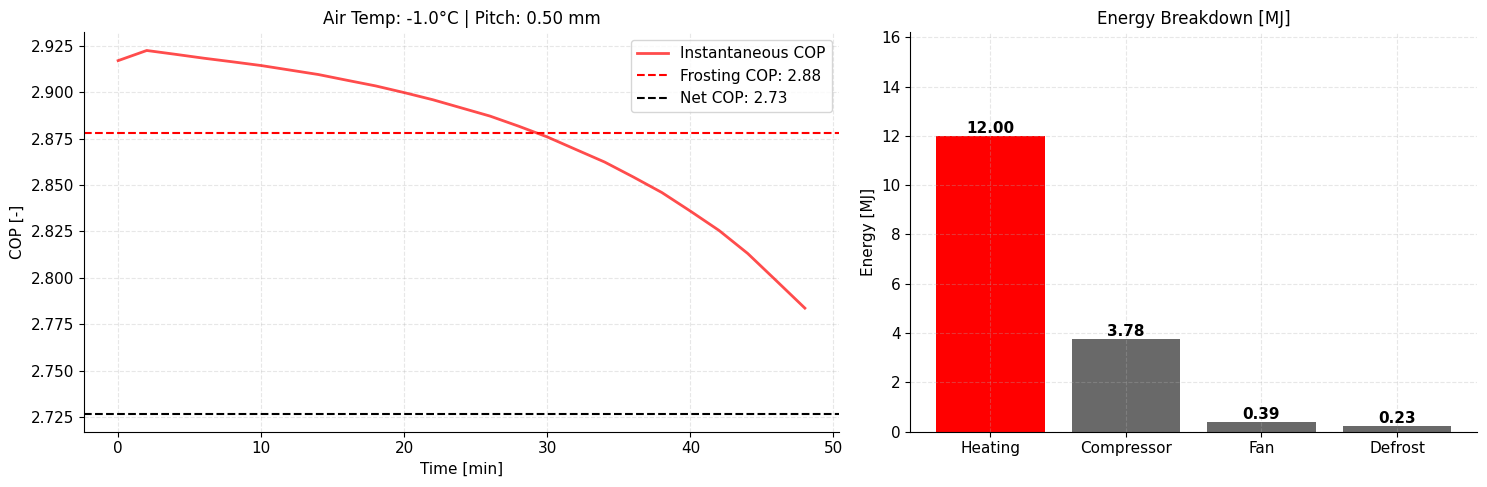

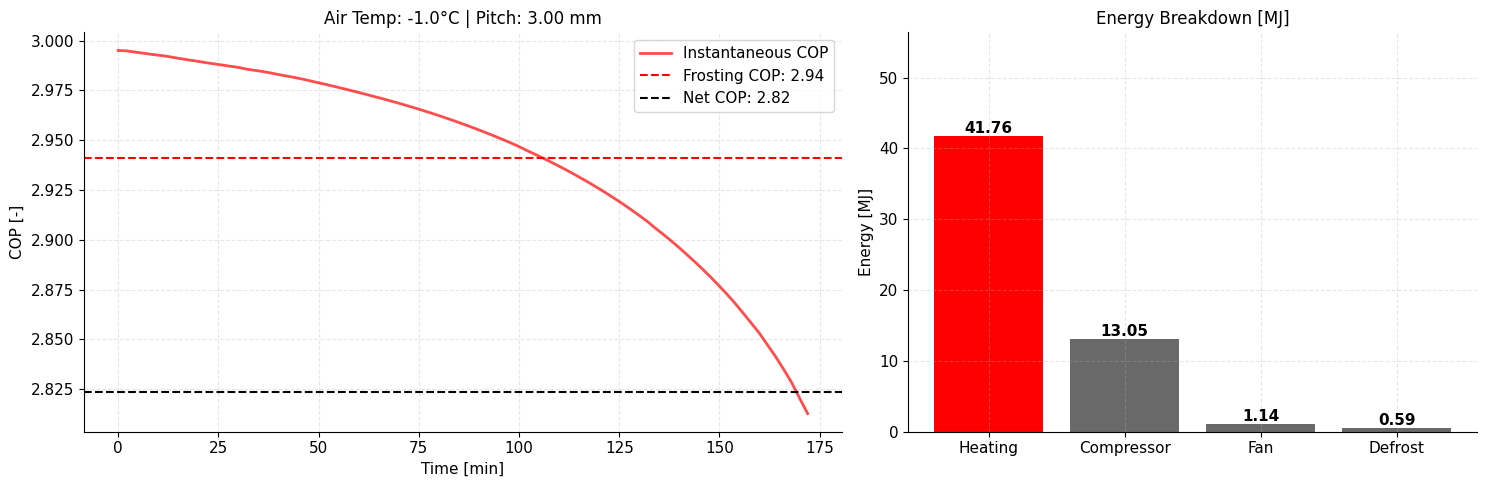


Processing Dataset: Air Temp: -4.0°C (8 runs)...


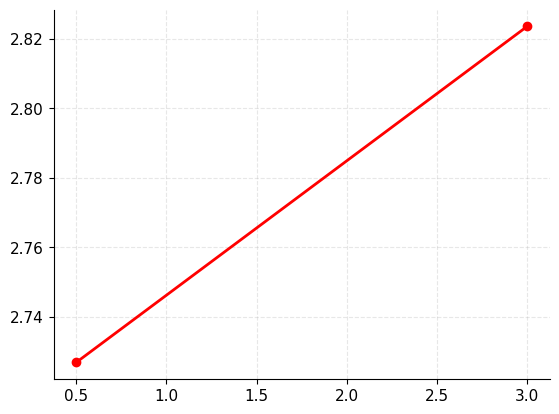

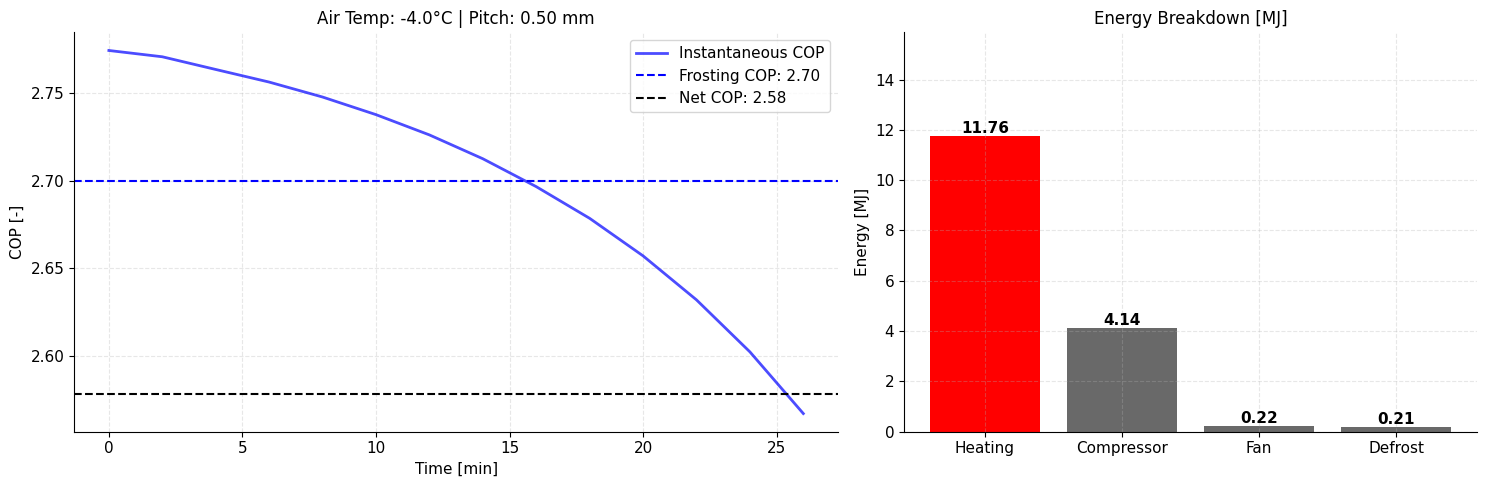

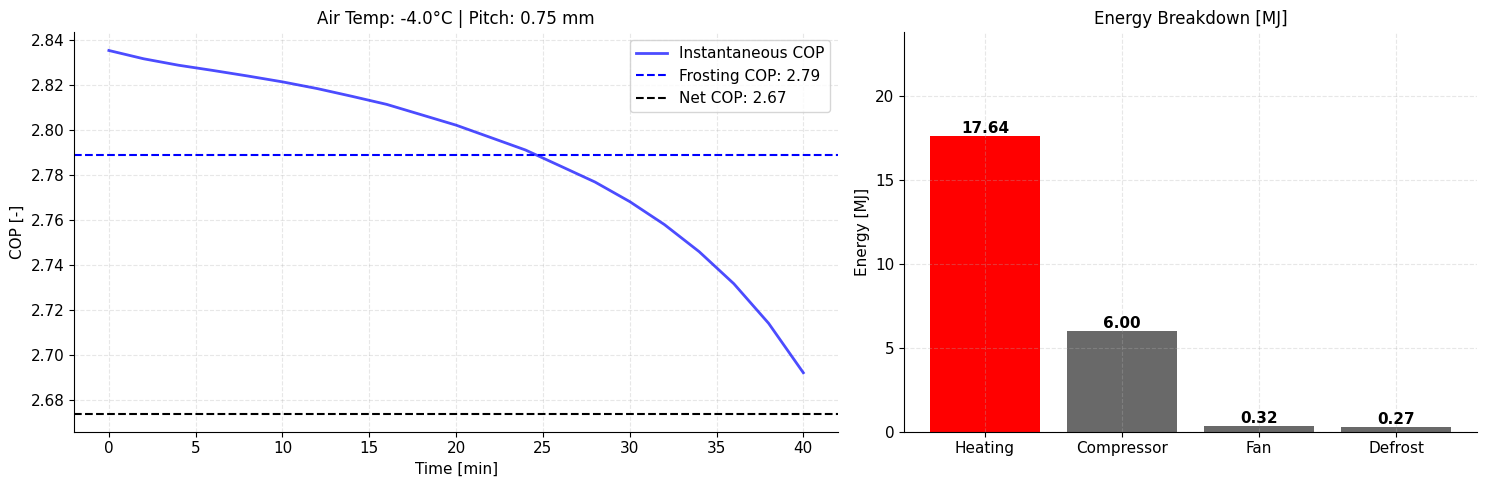

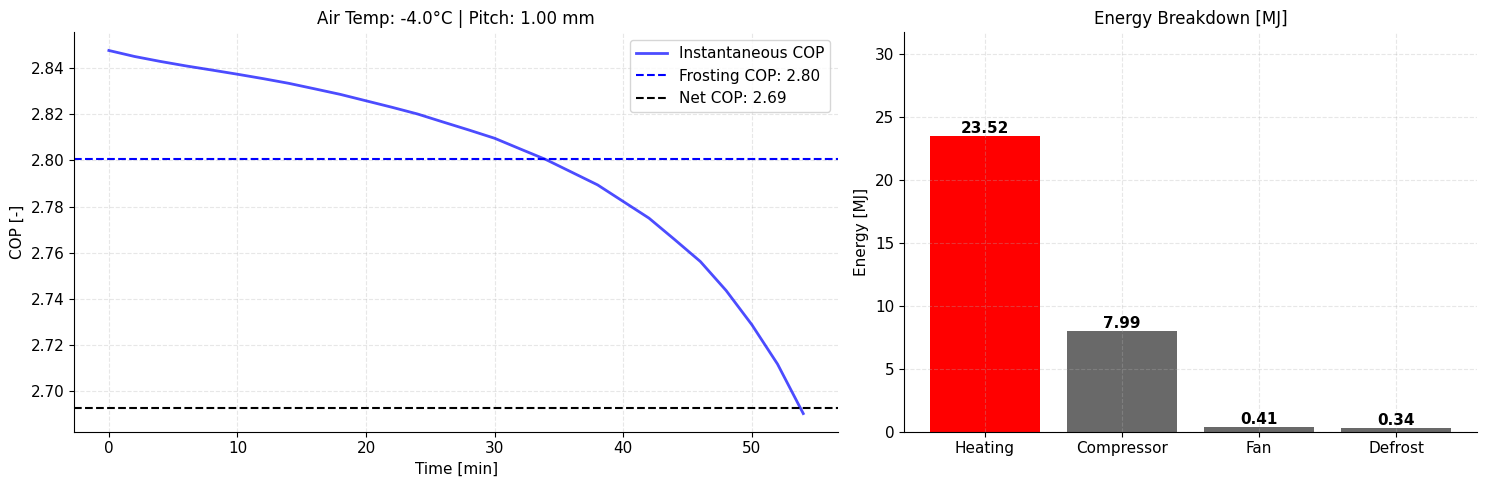

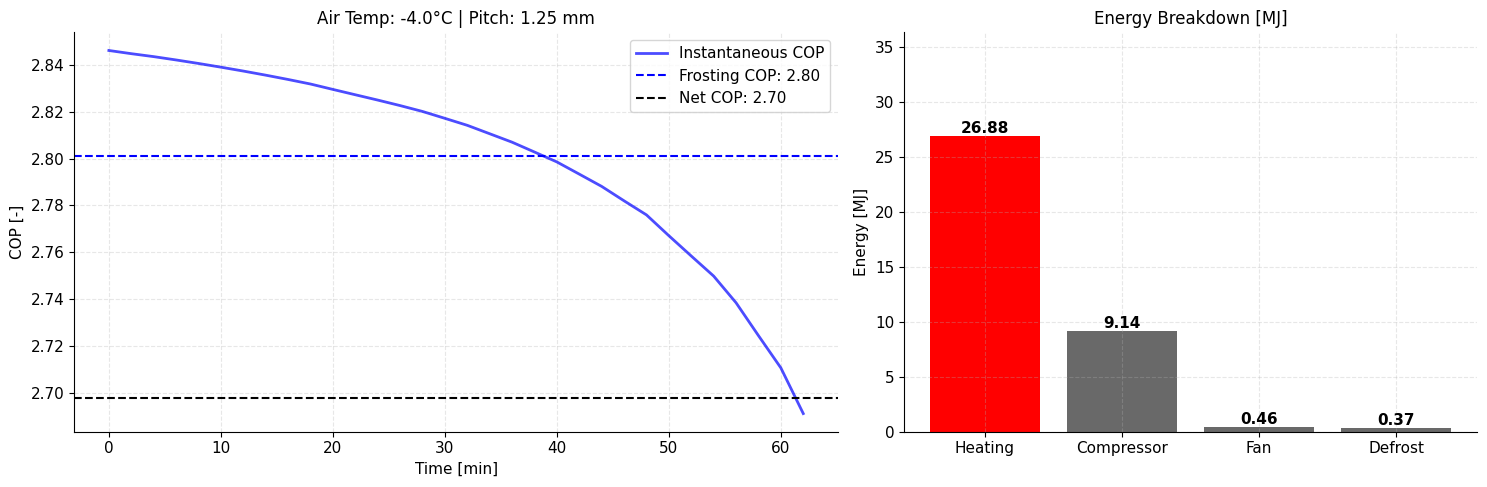

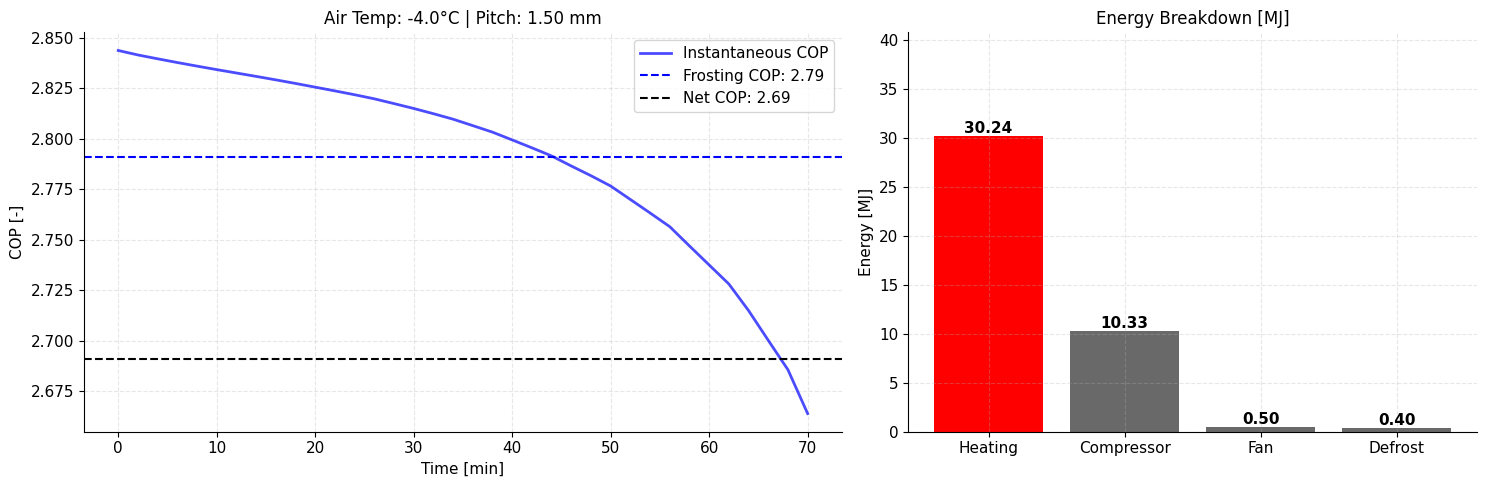

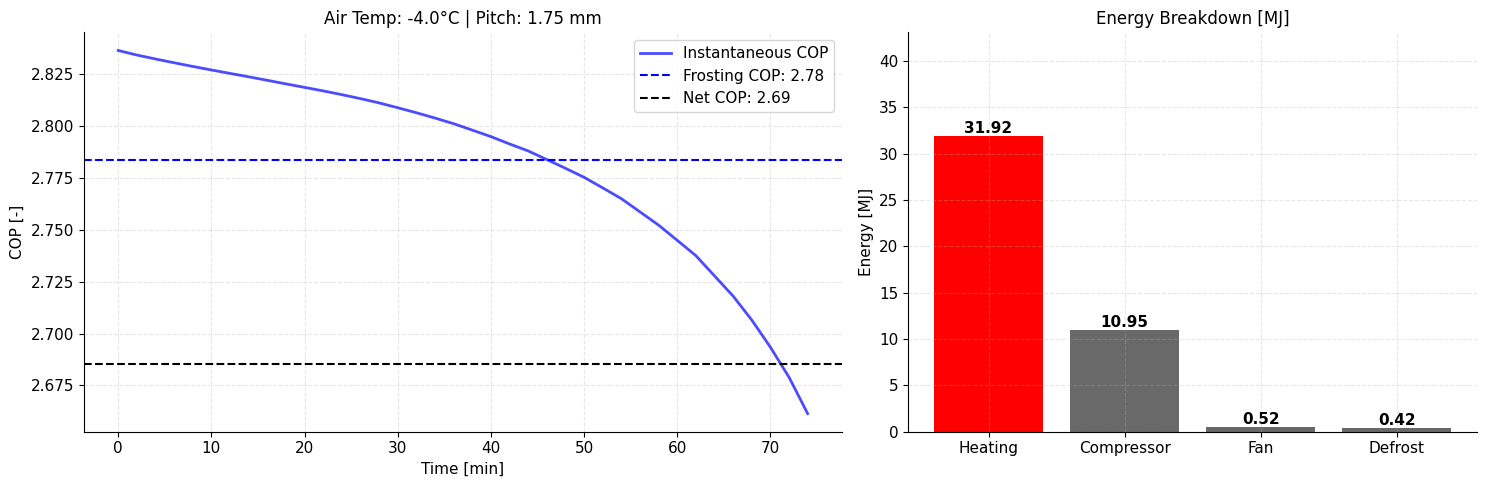

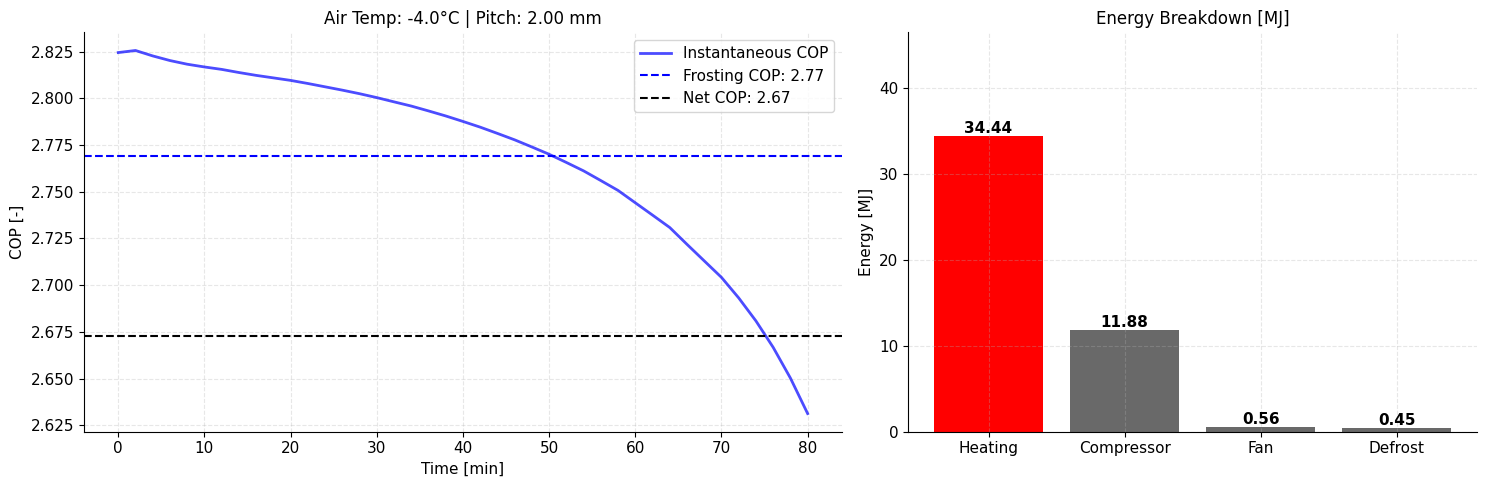

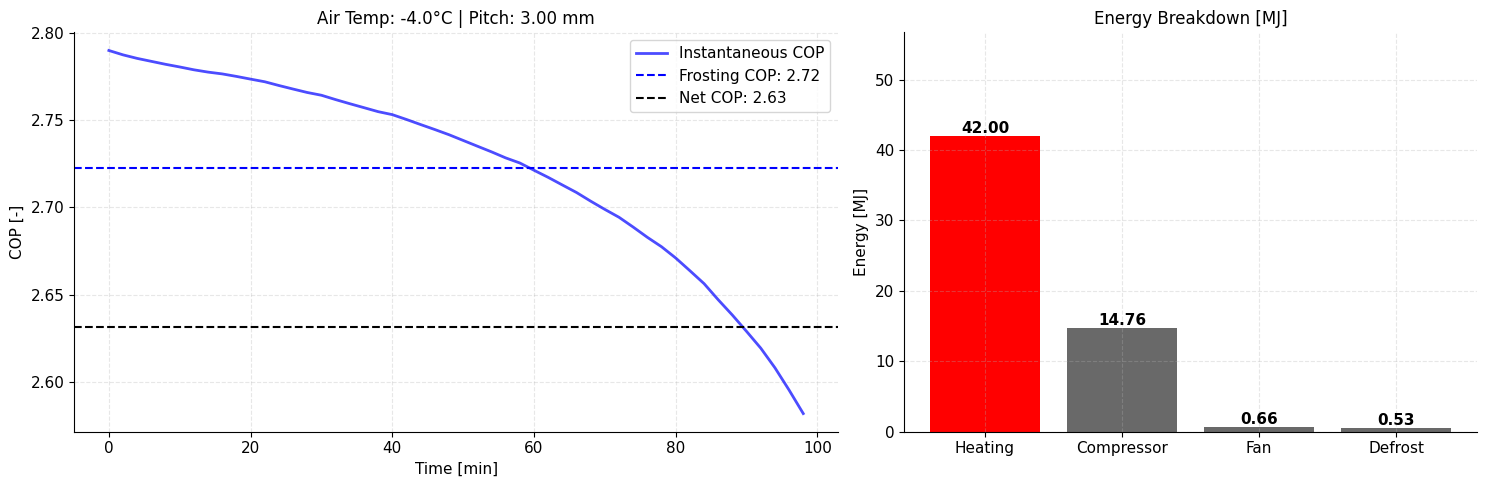


Processing Dataset: Air Temp: -7.0°C (8 runs)...


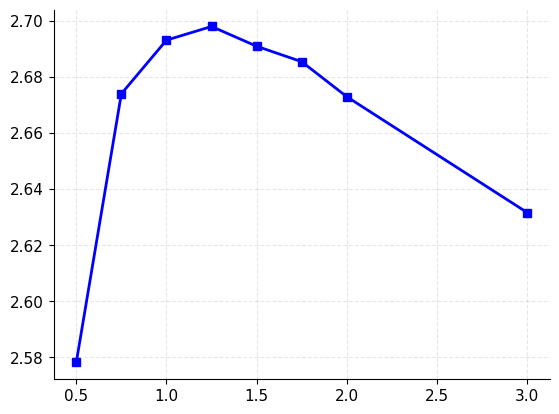

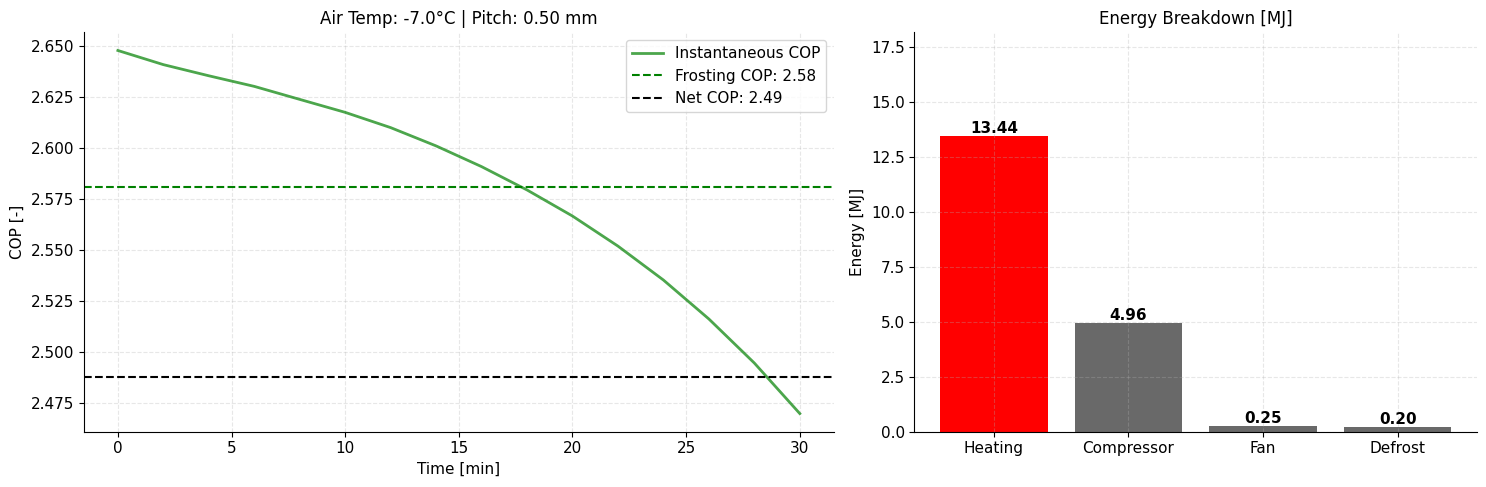

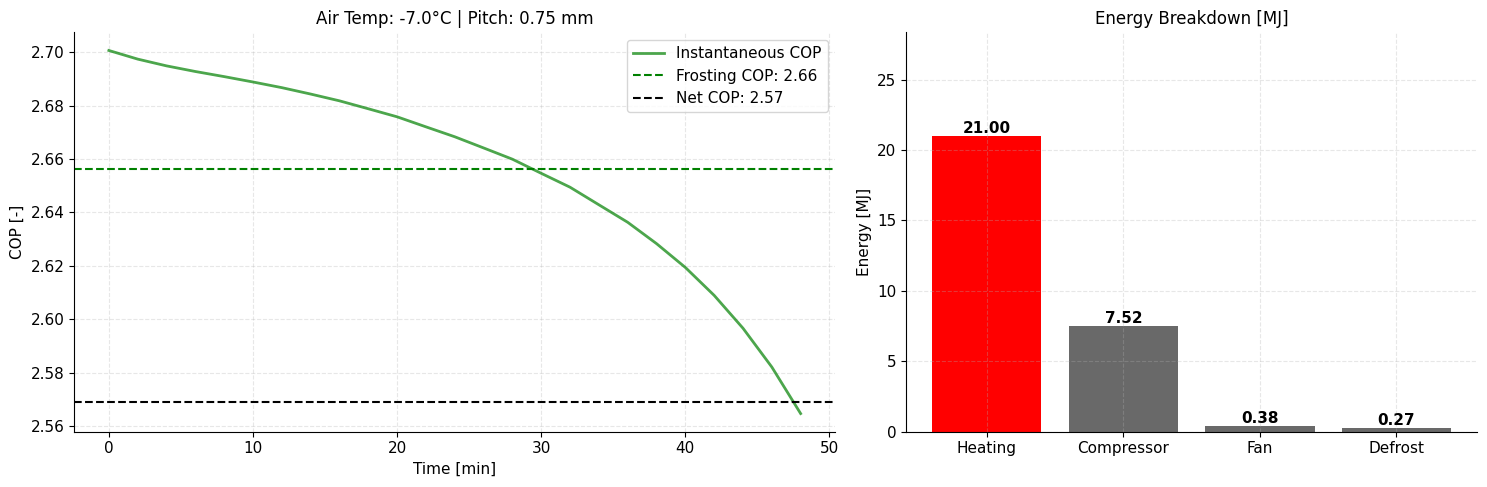

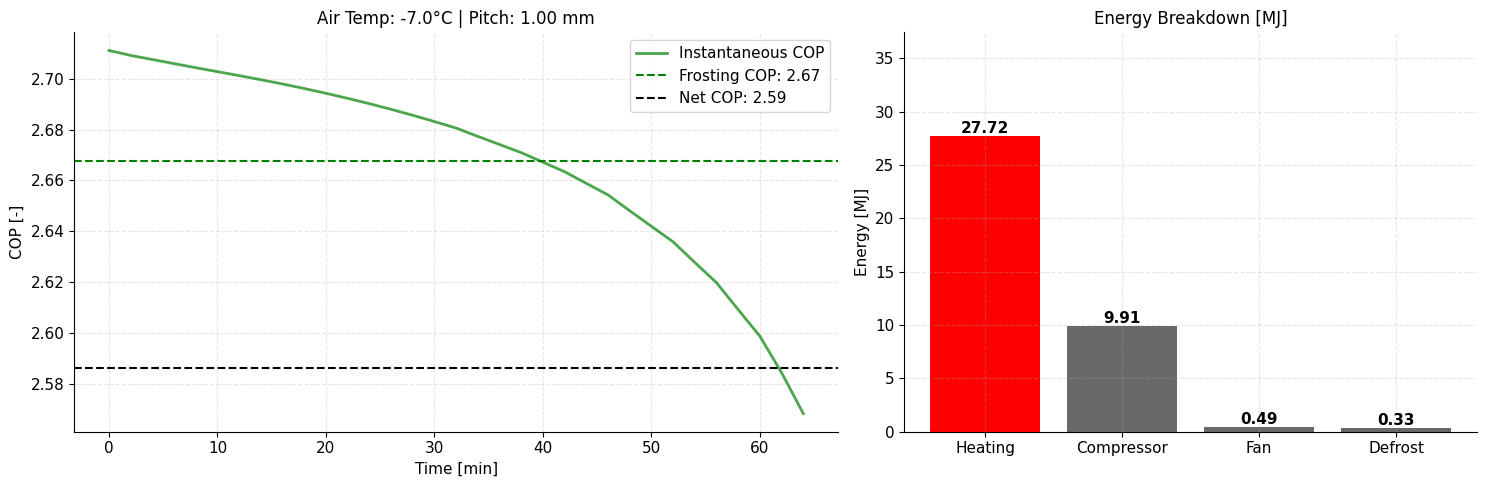

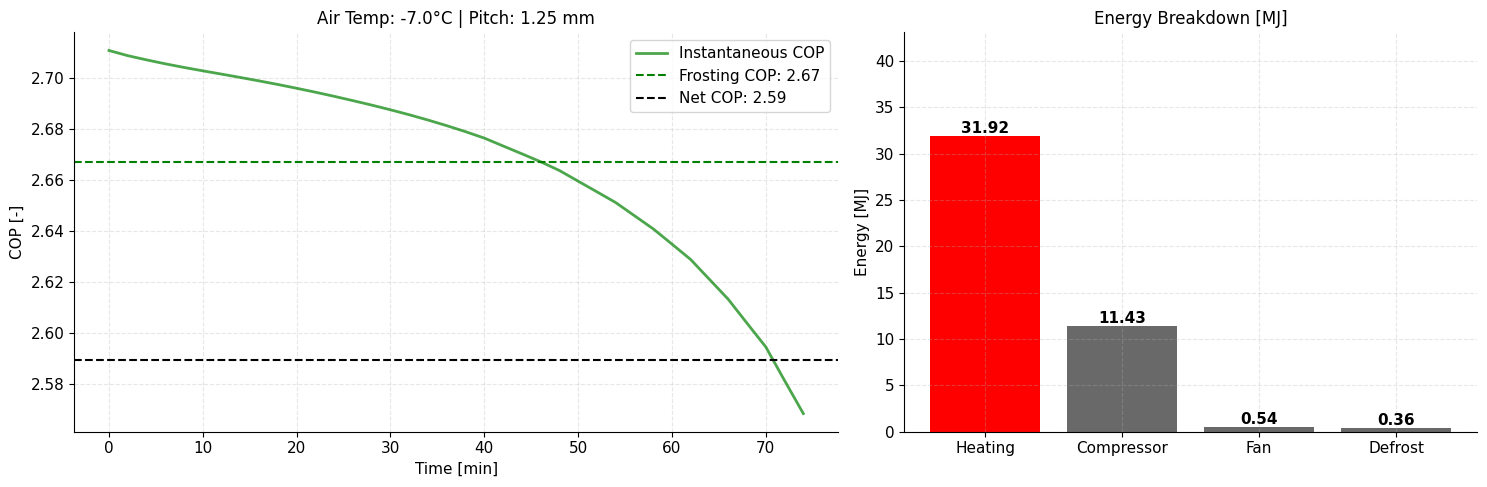

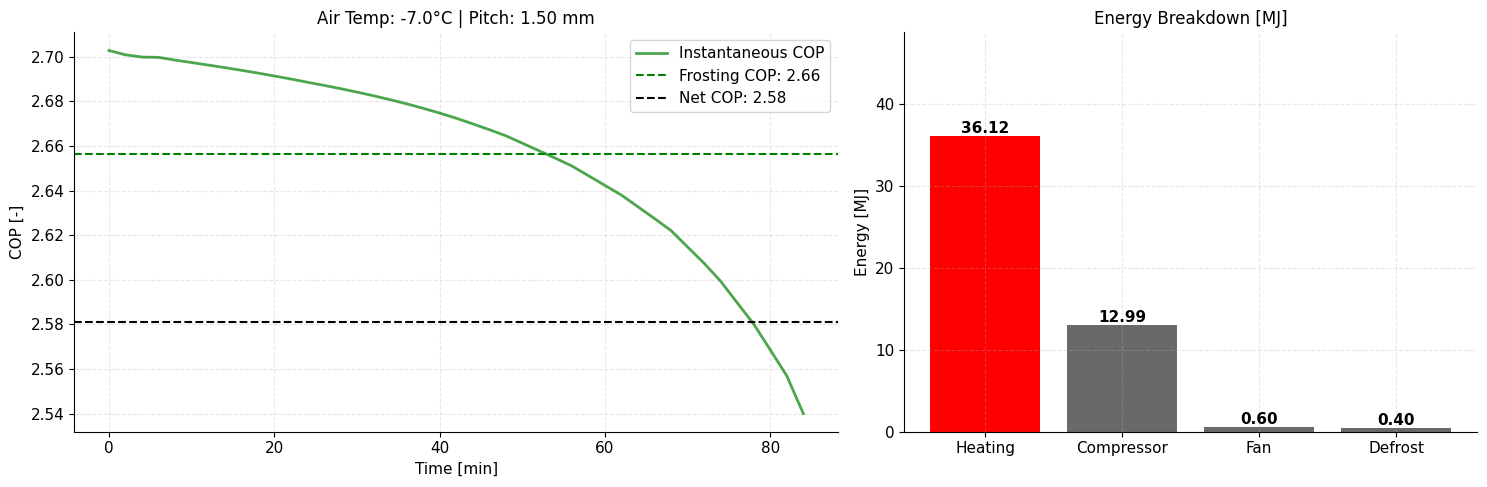

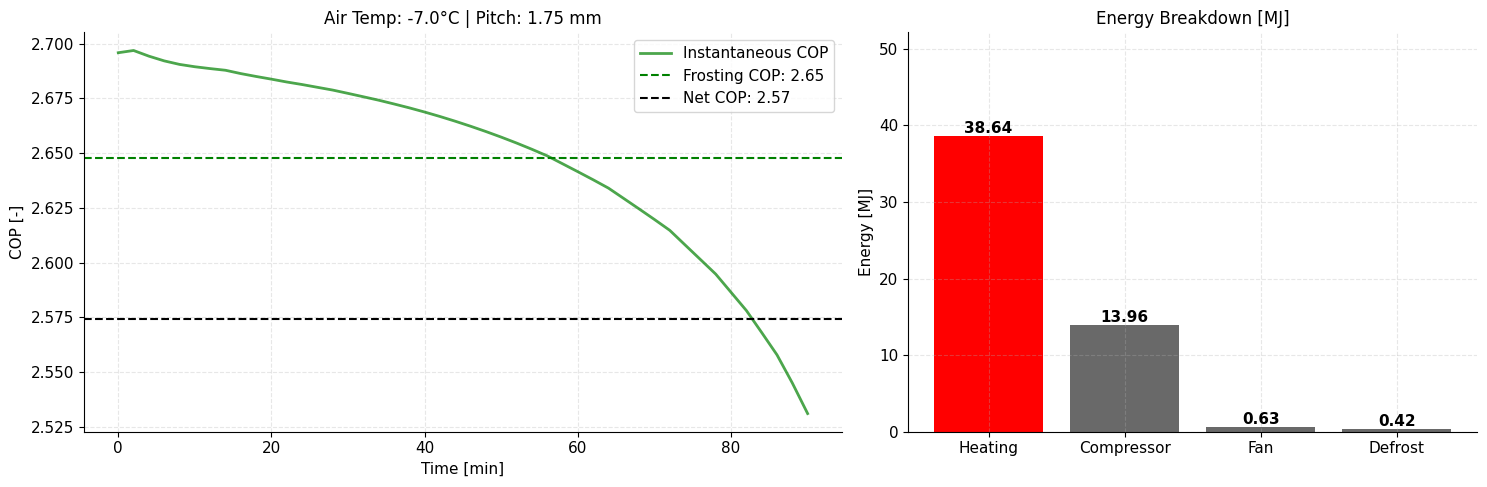

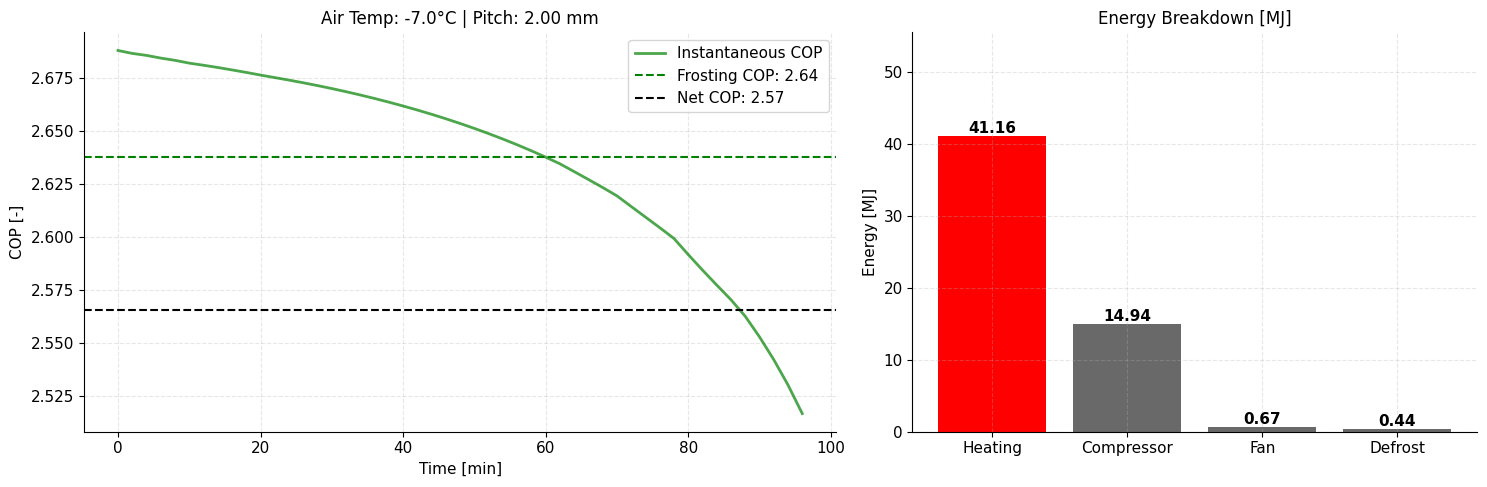

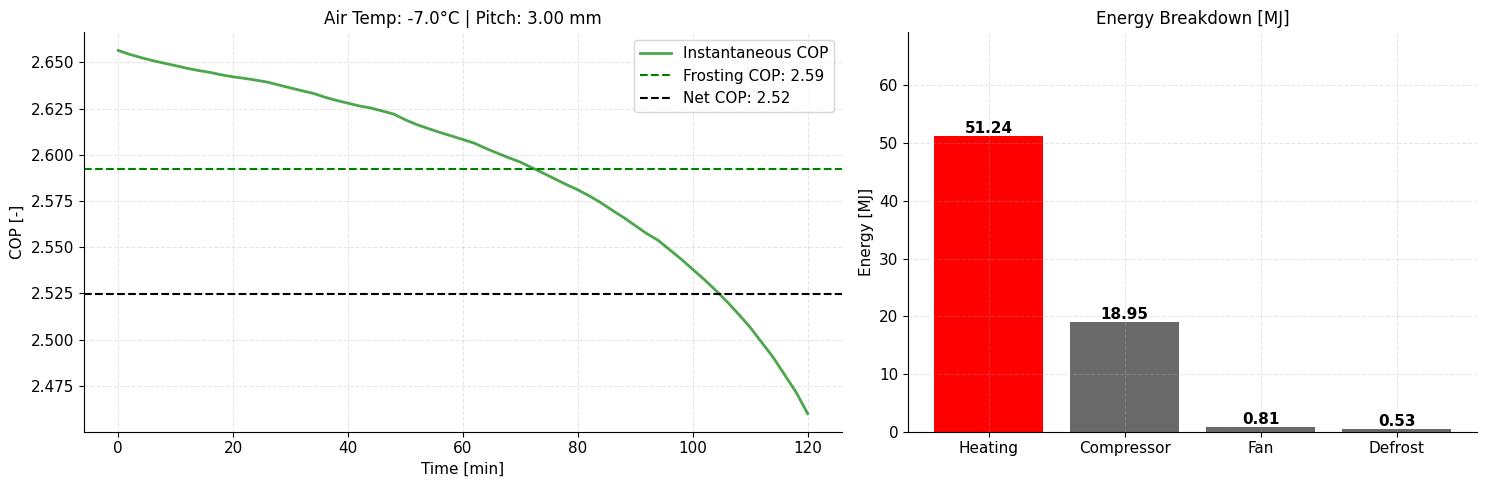

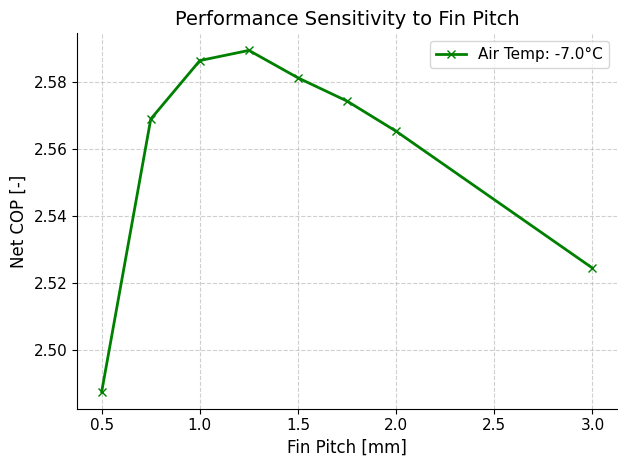

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. CONSTANTS & INPUT SETUP
# =============================================================================
ETA_DEFROST_HEATER = 0.45
CP_ICE = 2100.0      # J/kg*K
H_FUSION = 334000.0  # J/kg (Latent heat)

# Define the datasets to process
datasets_to_process = []

if 'all_results_1' in locals() and len(all_results_1) > 0:
    datasets_to_process.append(("Air Temp: -1.0°C", all_results_1, "red", "o"))

if 'all_results_2' in locals() and len(all_results_2) > 0:
    datasets_to_process.append(("Air Temp: -4.0°C", all_results_2, "blue", "s"))

if 'all_results_3' in locals() and len(all_results_3) > 0:
    datasets_to_process.append(("Air Temp: -7.0°C", all_results_3, "green", "x"))

if not datasets_to_process:
    if 'all_results' in locals() and len(all_results) > 0:
        datasets_to_process.append(("Generic Run", all_results, "green", "x"))
    elif 'results' in locals():
        single_run = results.copy()
        if 'fin_pitch' not in single_run: single_run['fin_pitch'] = 0.0
        datasets_to_process.append(("Single Run", [single_run], "green", "x"))
    else:
        print("⚠️ No data found! Please run the simulation cells first.")

plt.figure(figsize=(10, 6))

# =============================================================================
# 2. ITERATIVE ANALYSIS
# =============================================================================
for label, run_data, color, marker in datasets_to_process:
    
    print(f"\nProcessing Dataset: {label} ({len(run_data)} runs)...")
    
    summary_pitches = []
    summary_cop_net = []

    for i, res in enumerate(run_data):
        
        # --- A. Setup Variables ---
        pitch_val = res.get('fin_pitch', 0)
        time_min = np.array(res["time"])
        dt_seconds = TIME_STEP_SIZE # Ensure this is defined globally
        
        q_cond = np.array(res["Q_cond"])
        p_comp = np.array(res["compressor_power"])
        p_fan  = np.array(res["fan_power"])
        cop_inst = np.array(res["COP_wo_defrost"])

        # --- B. Energy Integration (Operation Phase - Separated) ---
        E_heating_useful = np.sum(q_cond) * dt_seconds
        E_comp_el = np.sum(p_comp) * dt_seconds
        E_fan_el = np.sum(p_fan) * dt_seconds
        E_input_operation = E_comp_el + E_fan_el

        # --- C. Defrost Penalty Calculation ---
        E_defrost_thermal = 0.0
        layer_keys = [k for k in res.keys() if k.startswith("m_frost_L")]
        
        for key_mass in layer_keys:
            layer_suffix = key_mass.split("_")[-1]
            key_temp = f"T_frost_avg_{layer_suffix}"
            
            m_final = res[key_mass][-1] / 1000 
            t_final = res[key_temp][-1] - 273.15 
            
            q_sensible = m_final * CP_ICE * (0.0 - t_final)
            q_latent   = m_final * H_FUSION
            E_defrost_thermal += (q_sensible + q_latent)

        E_defrost_electrical = E_defrost_thermal / ETA_DEFROST_HEATER

        # --- D. Compute Efficiency Metrics ---
        cop_avg_frosting = E_heating_useful / E_input_operation
        total_energy_input = E_input_operation + E_defrost_electrical
        cop_overall_net = E_heating_useful / total_energy_input

        summary_pitches.append(pitch_val)
        summary_cop_net.append(cop_overall_net)

        # --- E. Plotting ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1.5]})
        
        # Plot 1: Time Series
        ax1.plot(time_min, cop_inst, color=color, linewidth=2, alpha=0.7, label="Instantaneous COP")
        ax1.axhline(y=cop_avg_frosting, color=color, linestyle="--", label=f"Frosting COP: {cop_avg_frosting:.2f}")
        ax1.axhline(y=cop_overall_net, color="black", linestyle="--", label=f"Net COP: {cop_overall_net:.2f}")
        ax1.set_title(f"{label} | Pitch: {pitch_val*1000:.2f} mm", fontsize=12)
        ax1.set_xlabel("Time [min]")
        ax1.set_ylabel("COP [-]")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="best")

        # Plot 2: Energy Breakdown (Updated to 4 Bars)
        heating_mj = E_heating_useful / 1e6
        comp_mj = E_comp_el / 1e6
        fan_mj = E_fan_el / 1e6
        defrost_mj = E_defrost_electrical / 1e6
        
        labels_bar = ["Heating", "Compressor", "Fan", "Defrost"]
        values_bar = [heating_mj, comp_mj, fan_mj, defrost_mj]
        # Colors: Green for Heat, Dataset Color for Comp, Lighter version for Fan, Gray for Defrost
        colors_bar = ["red", "#696969", "#696969", "#696969"] 
        
        bars = ax2.bar(labels_bar, values_bar, color=colors_bar)
        ax2.set_title("Energy Breakdown [MJ]", fontsize=12)
        ax2.set_ylabel("Energy [MJ]")
        
        ax2.set_ylim(0, max(values_bar) * 1.35) 
        
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

    # Add to Summary Plot
    combined_data = sorted(zip(summary_pitches, summary_cop_net))
    if combined_data:
        sorted_pitches, sorted_cops = zip(*combined_data)
        p_vals_mm = [p * 1000 for p in sorted_pitches]
        plt.plot(p_vals_mm, sorted_cops, marker=marker, color=color, linewidth=2, label=label)

# =============================================================================
# 3. FINALIZE SUMMARY PLOT
# =============================================================================
if datasets_to_process:
    plt.title('Performance Sensitivity to Fin Pitch', fontsize=14)
    plt.xlabel('Fin Pitch [mm]', fontsize=12)
    plt.ylabel('Net COP [-]', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


Processing Dataset: Air Temp: -1.0°C...

Processing Dataset: Air Temp: -4.0°C...

Processing Dataset: Air Temp: -7.0°C...


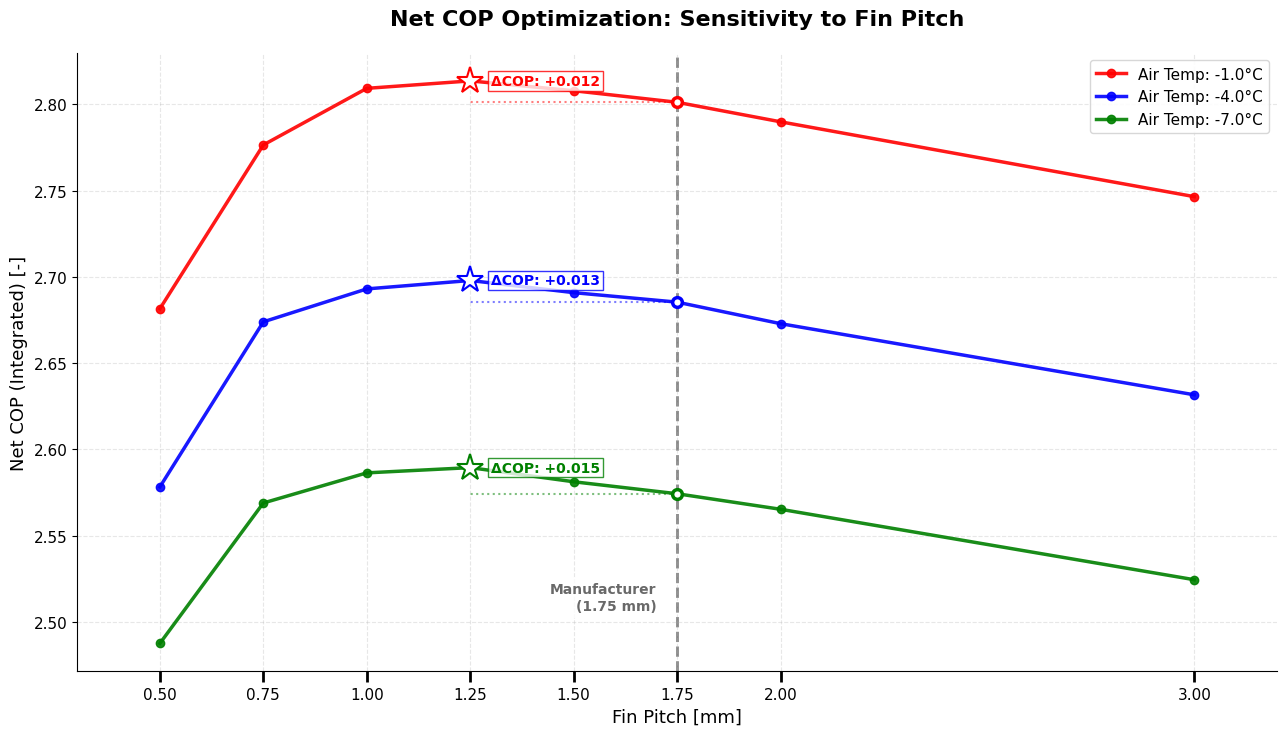

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import csv
import os

# =============================================================================
# 1. CONSTANTS & INPUT SETUP
# =============================================================================
ETA_DEFROST_HEATER = 0.45
CP_ICE = 2100.0      # J/kg*K
H_FUSION = 334000.0  # J/kg (Latent heat)
MANUFACTURER_PITCH_M = 0.00175

# Define the datasets to process
datasets_to_process = []

# Check for result lists
if 'all_results_1' in locals() and len(all_results_1) > 0:
    datasets_to_process.append(("Air Temp: -1.0°C", all_results_1, "red", "o"))

if 'all_results_2' in locals() and len(all_results_2) > 0:
    datasets_to_process.append(("Air Temp: -4.0°C", all_results_2, "blue", "o"))

if 'all_results_3' in locals() and len(all_results_3) > 0:
    datasets_to_process.append(("Air Temp: -7.0°C", all_results_3, "green", "o"))

# Fallback logic
if not datasets_to_process:
    if 'all_results' in locals() and len(all_results) > 0:
        datasets_to_process.append(("Generic Run", all_results, "forestgreen", "x"))
    elif 'results' in locals():
        single_run = results.copy()
        if 'fin_pitch' not in single_run: single_run['fin_pitch'] = 0.0
        datasets_to_process.append(("Single Run", [single_run], "forestgreen", "x"))
    else:
        print("⚠️ No data found! Please run the simulation cells first.")

full_csv_data = []

# =============================================================================
# 2. PLOT SETUP (Aesthetics)
# =============================================================================
# Set a clean style manually for consistent beauty
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(13, 7.5))

# =============================================================================
# 3. ITERATIVE ANALYSIS & PLOTTING
# =============================================================================
for label, run_data, color, marker in datasets_to_process:
    
    print(f"\nProcessing Dataset: {label}...")
    
    plot_pitches = []
    plot_cops = []

    # --- Process Runs ---
    for res in run_data:
        pitch_val = res.get('fin_pitch', 0)
        time_min = np.array(res["time"])
        dt_seconds = TIME_STEP_SIZE
        
        q_cond = np.array(res["Q_cond"])
        p_comp = np.array(res["compressor_power"])
        p_fan  = np.array(res["fan_power"])

        E_heating_useful = np.sum(q_cond) * dt_seconds
        E_input_operation = np.sum(p_comp + p_fan) * dt_seconds

        # Defrost Energy
        E_defrost_thermal = 0.0
        total_frost_mass_kg = 0.0
        layer_keys = [k for k in res.keys() if k.startswith("m_frost_L")]
        
        for key_mass in layer_keys:
            layer_suffix = key_mass.split("_")[-1]
            key_temp = f"T_frost_avg_{layer_suffix}"
            m_final = res[key_mass][-1] / 1000
            t_final = res[key_temp][-1] - 273.15
            
            total_frost_mass_kg += m_final
            q_sensible = m_final * CP_ICE * (0.0 - t_final)
            q_latent   = m_final * H_FUSION
            E_defrost_thermal += (q_sensible + q_latent)

        E_defrost_electrical = E_defrost_thermal / ETA_DEFROST_HEATER

        # Efficiency
        cop_operational = E_heating_useful / E_input_operation if E_input_operation > 0 else 0
        total_energy_input = E_input_operation + E_defrost_electrical
        cop_overall_net = E_heating_useful / total_energy_input if total_energy_input > 0 else 0

        plot_pitches.append(pitch_val)
        plot_cops.append(cop_overall_net)

        # Save to CSV data
        full_csv_data.append({
            "Dataset_Label": label,
            "Fin_Pitch_mm": round(pitch_val * 1000, 3),
            "Duration_min": round(time_min[-1], 1),
            "Total_Frost_Mass_kg": round(total_frost_mass_kg, 4),
            "E_Heating_Output_kJ": round(E_heating_useful / 1000, 2),
            "E_Input_Operation_kJ": round(E_input_operation / 1000, 2),
            "E_Defrost_Electrical_kJ": round(E_defrost_electrical / 1000, 2),
            "COP_Operational": round(cop_operational, 3),
            "COP_Net": round(cop_overall_net, 4)
        })

    # --- Plotting This Series ---
    combined_plot_data = sorted(zip(plot_pitches, plot_cops))
    
    if combined_plot_data:
        sorted_pitches, sorted_cops = zip(*combined_plot_data)
        p_vals_mm = np.array([p * 1000 for p in sorted_pitches])
        cops = np.array(sorted_cops)
        
        # 1. Main Line
        ax.plot(p_vals_mm, cops, marker=marker, color=color, 
                linewidth=2.5, label=label, alpha=0.9, zorder=3)
        
        # 2. Find Max Point
        max_cop = np.max(cops)
        max_idx = np.argmax(cops)
        max_pitch = p_vals_mm[max_idx]
        
        # 3. Interpolate Reference Point (Manufacturer Standard)
        man_pitch_mm = MANUFACTURER_PITCH_M * 1000
        cop_ref = np.interp(man_pitch_mm, p_vals_mm, cops)
        
        # 4. Highlight Max (Star)
        ax.plot(max_pitch, max_cop, marker='*', markersize=20, 
                color='white', markeredgecolor=color, markeredgewidth=1.5, 
                linestyle='None', zorder=10)

        # 5. Visualise the "Gain" (Improvement)
        delta_cop = max_cop - cop_ref
        delta_pct = (delta_cop / cop_ref) * 100
        
        # Only draw annotation if there is a meaningful difference (>0.01)
        if delta_cop > 0.005:
            # A. Draw faint dashed line from Ref level across to Max X
            ax.hlines(y=cop_ref, xmin=man_pitch_mm, xmax=max_pitch, 
                      colors=color, linestyles=':', alpha=0.5, linewidth=1.5)

            ax.text(max_pitch + 0.05, max_cop, 
                    f"\u0394COP: +{delta_cop:.3f}", 
                    fontsize=10, fontweight='bold', color=color, va='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=color, pad=2))
        
        # 6. Mark the Reference Point intersection on the curve
        ax.plot(man_pitch_mm, cop_ref, marker='o', color='white', markeredgecolor=color, markersize=7, markeredgewidth=2.5, zorder=5) 


# =============================================================================
# 4. FINAL TOUCHES
# =============================================================================
if datasets_to_process:
    
    # --- 1. SET CUSTOM TICKS AT INDIVIDUAL PITCH VALUES ---
    # Collect all unique pitch values plotted across all datasets
    all_pitch_values = set()
    for label, run_data, color, marker in datasets_to_process:
        for res in run_data:
            all_pitch_values.add(round(res.get('fin_pitch', 0) * 1000, 3))
    
    # Add the manufacturer pitch to the ticks if it's not already there
    man_pitch_mm = MANUFACTURER_PITCH_M * 1000
    all_pitch_values.add(man_pitch_mm)
    
    # Apply the sorted values to the X-axis
    sorted_ticks = sorted(list(all_pitch_values))
    ax.set_xticks(sorted_ticks)
    ax.tick_params(axis='x', which='major', length=8, width=2, direction='out', colors='black')

    # --- 2. Manufacturer Vertical Line ---
    ax.axvline(x=man_pitch_mm, color='dimgray', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
    
    # Label for Manufacturer Line
    y_min, y_max = ax.get_ylim()
    ax.text(man_pitch_mm - 0.05, y_min + (y_max - y_min)*0.1, 
            f'Manufacturer\n({man_pitch_mm} mm)', 
            color='dimgray', fontsize=10, ha='right', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Labels and Title
    ax.set_title('Net COP Optimization: Sensitivity to Fin Pitch', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Fin Pitch [mm]', fontsize=13)
    ax.set_ylabel('Net COP (Integrated) [-]', fontsize=13)
    
    # Clean Legend
    ax.legend(fontsize=11, loc='best', frameon=True, framealpha=0.9, edgecolor='lightgray')
    
    # Adjust limits to see all ticks clearly
    ax.set_xlim(left=min(sorted_ticks) - 0.2, right=max(sorted_ticks) + 0.2)
    
    plt.tight_layout()
    plt.show()

C:\Users\mbc-nba\AppData\Local\Temp\ipykernel_18472\640954053.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20', num_groups)


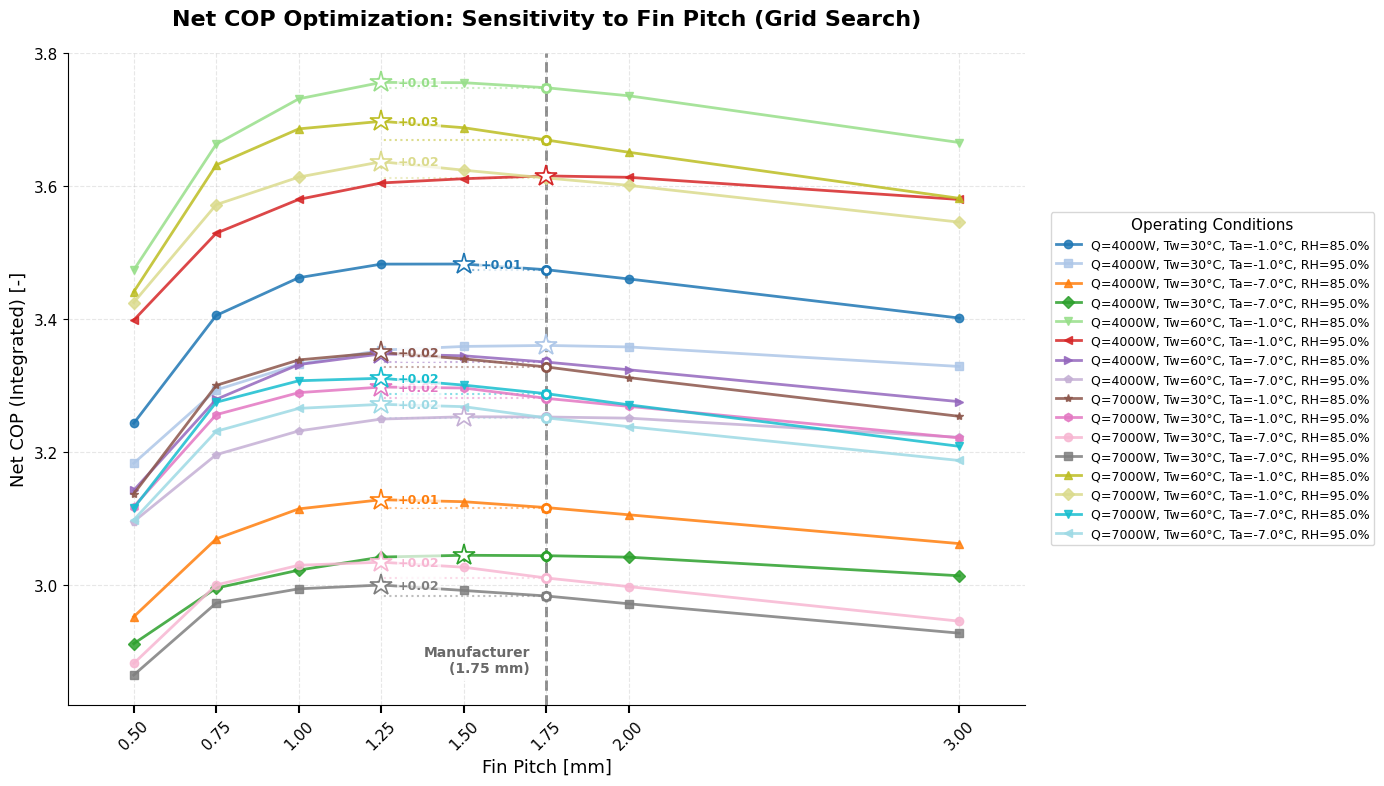

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =============================================================================
# 1. CONSTANTS & INPUT SETUP
# =============================================================================
TIME_STEP_SIZE = 120         # seconds (from simulation setup)
ETA_DEFROST_HEATER = 0.45
CP_ICE = 2100.0              # J/kg*K
H_FUSION = 334000.0          # J/kg (Latent heat)
MANUFACTURER_PITCH_M = 0.00175

# Load the single grand results file
DATA_FILE = "grand_simulation_results.pkl"

try:
    with open(DATA_FILE, "rb") as f:
        all_runs_data = pickle.load(f)
except FileNotFoundError:
    print(f"⚠️ Could not find {DATA_FILE}. Please run the simulation first.")
    all_runs_data = []

# Group data by operating conditions (excluding pitch)
# group_key: (q_cond, t_water, t_air, rh) -> list of runs
grouped_datasets = {}

for run in all_runs_data:
    if "error" in run:
        continue # Skip failed runs
        
    inputs = run["metadata"]["inputs"]
    q_cond = inputs["q_cond"]
    t_water = inputs["t_water"]
    t_air = inputs["t_air"]
    rh = inputs["rh"]
    pitch = inputs["pitch"]
    
    group_key = (q_cond, t_water, t_air, rh)
    
    if group_key not in grouped_datasets:
        grouped_datasets[group_key] = []
        
    grouped_datasets[group_key].append((pitch, run))

# =============================================================================
# 2. PLOT SETUP (Aesthetics)
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 8))

# Generate colors and markers for potentially many lines
num_groups = len(grouped_datasets)
color_map = cm.get_cmap('tab20', num_groups)
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

all_pitch_values = set()

# =============================================================================
# 3. ITERATIVE ANALYSIS & PLOTTING
# =============================================================================
for i, (group_key, runs) in enumerate(grouped_datasets.items()):
    q_cond, t_water, t_air, rh = group_key
    label = f"Q={q_cond}W, Tw={t_water}°C, Ta={t_air}°C, RH={rh}%"
    
    color = color_map(i)
    marker = markers[i % len(markers)]
    
    plot_pitches = []
    plot_cops = []

    # --- Process Runs for this group ---
    for pitch_val, res in runs:
        all_pitch_values.add(round(pitch_val * 1000, 3))
        
        time_min = np.array(res["time"])
        dt_seconds = TIME_STEP_SIZE
        
        q_cond_arr = np.array(res["Q_cond"])
        p_comp = np.array(res["compressor_power"])
        p_fan  = np.array(res["fan_power"])

        E_heating_useful = np.sum(q_cond_arr) * dt_seconds
        E_input_operation = np.sum(p_comp + p_fan) * dt_seconds

        # Defrost Energy
        E_defrost_thermal = 0.0
        layer_keys = [k for k in res.keys() if k.startswith("m_frost_L")]
        
        for key_mass in layer_keys:
            layer_suffix = key_mass.split("_")[-1]
            key_temp = f"T_frost_avg_{layer_suffix}"
            m_final = res[key_mass][-1] / 1000
            t_final = res[key_temp][-1] - 273.15
            
            q_sensible = m_final * CP_ICE * (0.0 - t_final)
            q_latent   = m_final * H_FUSION
            E_defrost_thermal += (q_sensible + q_latent)

        E_defrost_electrical = E_defrost_thermal / ETA_DEFROST_HEATER

        # Efficiency
        total_energy_input = E_input_operation + E_defrost_electrical
        cop_overall_net = E_heating_useful / total_energy_input if total_energy_input > 0 else 0

        plot_pitches.append(pitch_val)
        plot_cops.append(cop_overall_net)

    # --- Plotting This Series ---
    combined_plot_data = sorted(zip(plot_pitches, plot_cops))
    
    if combined_plot_data:
        sorted_pitches, sorted_cops = zip(*combined_plot_data)
        p_vals_mm = np.array([p * 1000 for p in sorted_pitches])
        cops = np.array(sorted_cops)
        
        # 1. Main Line
        ax.plot(p_vals_mm, cops, marker=marker, color=color, 
                linewidth=2.0, label=label, alpha=0.85, zorder=3)
        
        # 2. Find Max Point
        max_cop = np.max(cops)
        max_idx = np.argmax(cops)
        max_pitch = p_vals_mm[max_idx]
        
        # 3. Interpolate Reference Point (Manufacturer Standard)
        man_pitch_mm = MANUFACTURER_PITCH_M * 1000
        # Only interpolate if manufacturer pitch is within our simulated bounds
        if min(p_vals_mm) <= man_pitch_mm <= max(p_vals_mm):
            cop_ref = np.interp(man_pitch_mm, p_vals_mm, cops)
            
            # 4. Highlight Max (Star)
            ax.plot(max_pitch, max_cop, marker='*', markersize=16, 
                    color='white', markeredgecolor=color, markeredgewidth=1.2, 
                    linestyle='None', zorder=10)

            # 5. Visualise the "Gain" (Improvement)
            delta_cop = max_cop - cop_ref
            
            # Only draw annotation if there is a meaningful difference
            if delta_cop > 0.005:
                # Faint dashed line from Ref level across to Max X
                ax.hlines(y=cop_ref, xmin=man_pitch_mm, xmax=max_pitch, 
                          colors=color, linestyles=':', alpha=0.5, linewidth=1.5)

                ax.text(max_pitch + 0.05, max_cop, 
                        f"+{delta_cop:.2f}", 
                        fontsize=9, fontweight='bold', color=color, va='center',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
            # 6. Mark the Reference Point intersection on the curve
            ax.plot(man_pitch_mm, cop_ref, marker='o', color='white', 
                    markeredgecolor=color, markersize=6, markeredgewidth=2, zorder=5) 

# =============================================================================
# 4. FINAL TOUCHES
# =============================================================================
if all_pitch_values:
    # Add manufacturer pitch to ticks
    man_pitch_mm = MANUFACTURER_PITCH_M * 1000
    all_pitch_values.add(man_pitch_mm)
    
    # Apply custom sorted x-ticks
    sorted_ticks = sorted(list(all_pitch_values))
    ax.set_xticks(sorted_ticks)
    ax.tick_params(axis='x', which='major', length=6, width=1.5, direction='out', colors='black', rotation=45)

    # Manufacturer Vertical Line
    ax.axvline(x=man_pitch_mm, color='dimgray', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
    
    # Label for Manufacturer Line
    y_min, y_max = ax.get_ylim()
    ax.text(man_pitch_mm - 0.05, y_min + (y_max - y_min)*0.05, 
            f'Manufacturer\n({man_pitch_mm} mm)', 
            color='dimgray', fontsize=10, ha='right', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Title & Labels
    ax.set_title('Net COP Optimization: Sensitivity to Fin Pitch (Grid Search)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Fin Pitch [mm]', fontsize=13)
    ax.set_ylabel('Net COP (Integrated) [-]', fontsize=13)
    
    # Legend setup (moved outside to prevent overlapping lines since there are many combinations)
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5), 
              frameon=True, framealpha=0.9, edgecolor='lightgray', title="Operating Conditions")
    
    ax.set_xlim(left=min(sorted_ticks) - 0.2, right=max(sorted_ticks) + 0.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid data found to plot.")

Analyzing Physics for: Air Temp: -4.0°C


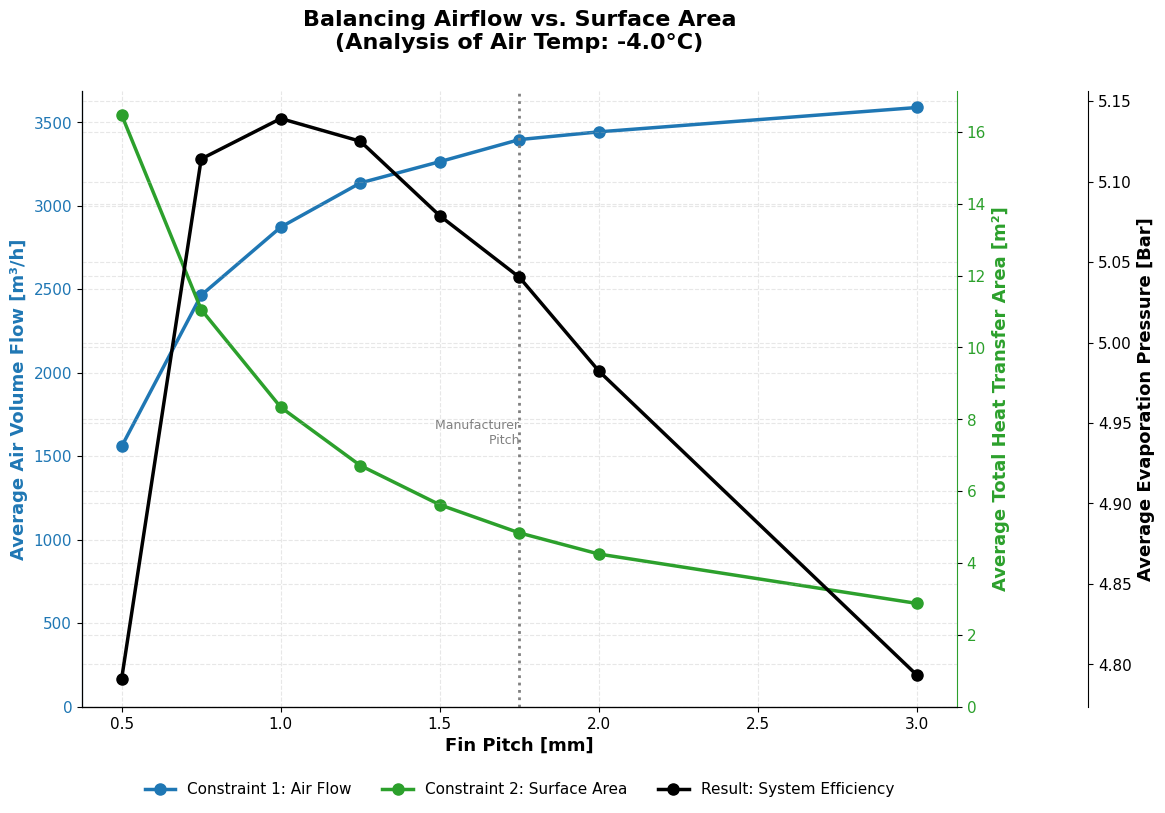

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. CONSTANTS & INPUT SETUP
# =============================================================================
MANUFACTURER_PITCH_M = 0.00175

# Define the datasets to process
datasets_to_process = []

if 'all_results_1' in locals() and len(all_results_1) > 0:
    datasets_to_process.append(("Air Temp: -1.0°C", all_results_1))
if 'all_results_2' in locals() and len(all_results_2) > 0:
    datasets_to_process.append(("Air Temp: -4.0°C", all_results_2))
if 'all_results_3' in locals() and len(all_results_3) > 0:
    datasets_to_process.append(("Air Temp: -7.0°C", all_results_3))

# Fallback
if not datasets_to_process:
    if 'all_results' in locals() and len(all_results) > 0:
        datasets_to_process.append(("Generic Run", all_results))
    elif 'results' in locals():
        single_run = results.copy()
        if 'fin_pitch' not in single_run: single_run['fin_pitch'] = 0.0
        datasets_to_process.append(("Single Run", [single_run]))

# =============================================================================
# 2. SELECT DATA
# =============================================================================
if not datasets_to_process:
    print("⚠️ No data found! Please run the simulation cells first.")
    selected_label, selected_data = "No Data", []
else:
    # Prefer the middle dataset (-4°C)
    idx = 1 if len(datasets_to_process) >= 2 else 0
    selected_label, selected_data = datasets_to_process[idx]
    print(f"Analyzing Physics for: {selected_label}")

# =============================================================================
# 3. EXTRACT VARIABLES
# =============================================================================
plot_pitches = []
avg_flow = []
avg_pevap = []
avg_area = []

for res in selected_data:
    pitch_val = res.get('fin_pitch', 0)
    
    # --- VARIABLE 1: Air Volume Flow ---
    flow_val = np.mean(res.get("v_dot_air", [0]))
    
    # --- VARIABLE 2: Total Surface Area ---
    if "total_frost_area" in res:
        area_val = np.mean(res["total_frost_area"])
    else:
        area_val = np.mean(res.get("total_frost_area", [0]))

    # --- VARIABLE 3: Evaporation Pressure ---
    pevap_val = np.mean(res.get("p_evap", [0]))

    plot_pitches.append(pitch_val)
    avg_flow.append(flow_val)
    avg_pevap.append(pevap_val)
    avg_area.append(area_val)

# Sort
if plot_pitches:
    combined_data = sorted(zip(plot_pitches, avg_flow, avg_pevap, avg_area))
    sorted_pitches, sorted_flow, sorted_pevap, sorted_area = zip(*combined_data)
    
    x_mm = np.array(sorted_pitches) * 1000
    y_flow = np.array(sorted_flow)
    y_area = np.array(sorted_area)
    y_pevap = np.array(sorted_pevap) / 100000.0 # Bar

    # =============================================================================
    # 4. PLOTTING (With Fixed Spines)
    # =============================================================================
    plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

    fig, ax_flow = plt.subplots(figsize=(14, 8))
    fig.subplots_adjust(right=0.75) # Space for 3rd axis

    # --- 1. LEFT AXIS: AIR FLOW (Blue) ---
    color_flow = '#1f77b4' # Tab:Blue
    ax_flow.set_xlabel('Fin Pitch [mm]', fontsize=13, fontweight='bold')
    ax_flow.set_ylabel('Average Air Volume Flow [m³/h]', color=color_flow, fontsize=13, fontweight='bold')
    
    p1, = ax_flow.plot(x_mm, y_flow, color=color_flow, marker='o', markersize=8, linewidth=2.5, label='Constraint 1: Air Flow')
    ax_flow.tick_params(axis='y', labelcolor=color_flow)
    ax_flow.grid(True, alpha=0.3, linestyle='--')
    ax_flow.set_ylim(0, None)

    # --- 2. INNER RIGHT AXIS: SURFACE AREA (Green) ---
    ax_area = ax_flow.twinx()
    color_area = '#2ca02c' # Tab:Green
    ax_area.set_ylabel('Average Total Heat Transfer Area [m²]', color=color_area, fontsize=13, fontweight='bold')
    
    p2, = ax_area.plot(x_mm, y_area, color=color_area, marker='o', markersize=8, linewidth=2.5, label='Constraint 2: Surface Area')
    ax_area.tick_params(axis='y', labelcolor=color_area)
    ax_area.set_ylim(0, None)

    # --- 3. OUTER RIGHT AXIS: EVAP PRESSURE (Black) ---
    ax_pevap = ax_flow.twinx()
    color_pevap = 'black' 
    ax_pevap.spines["right"].set_position(("axes", 1.15)) # Offset spine
    ax_pevap.set_ylabel('Average Evaporation Pressure [Bar]', color=color_pevap, fontsize=13, fontweight='bold')
    
    p3, = ax_pevap.plot(x_mm, y_pevap, color=color_pevap, marker='o', markersize=8, linewidth=2.5, label='Result: System Efficiency')
    ax_pevap.tick_params(axis='y', labelcolor=color_pevap)

    # --- 5. COLOR & VISIBILITY OF SPINES (The Fix) ---
    # Left Axis
    ax_flow.spines['left'].set_visible(True)
    ax_flow.spines['left'].set_color(color_flow)
    
    # Inner Right Axis (Area) - Explicitly set visible
    ax_area.spines['right'].set_visible(True)
    ax_area.spines['right'].set_color(color_area)
    
    # Outer Right Axis (Pressure) - Explicitly set visible
    ax_pevap.spines['right'].set_visible(True)
    ax_pevap.spines['right'].set_color(color_pevap)

    # Manufacturer Line
    man_pitch_mm = MANUFACTURER_PITCH_M * 1000
    ax_flow.axvline(x=man_pitch_mm, color='gray', linestyle=':', linewidth=2)
    ax_flow.text(man_pitch_mm, min(y_flow), ' Manufacturer\n Pitch', color='gray', fontsize=9, ha='right', va='bottom')

    # Legend
    lines = [p1, p2, p3] 
    ax_flow.legend(lines, [l.get_label() for l in lines], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=11)

    plt.title(f'Balancing Airflow vs. Surface Area\n(Analysis of {selected_label})', fontsize=16, pad=30, fontweight='bold')
    plt.show()

else:
    print("No data available.")